In [ ]:
.

# Preprocess


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.1/2.1 MB 22.5 MB/s eta 0:00:00


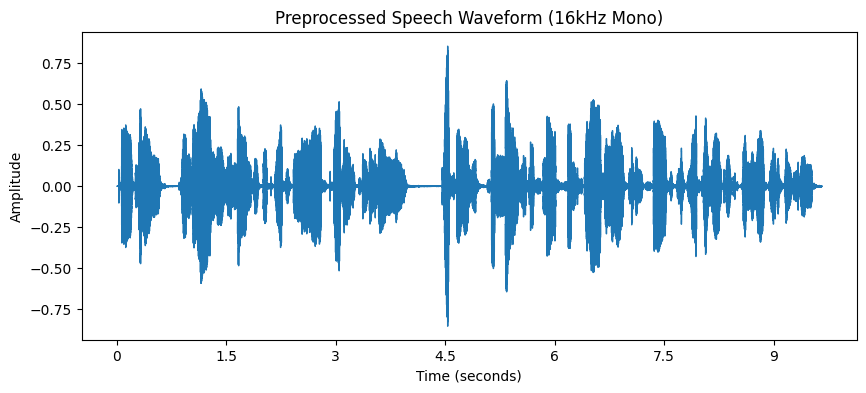

In [ ]:
!pip install torchcodec
import torchaudio
import torchaudio.transforms as T
import matplotlib.pyplot as plt
import librosa.display
waveform,sample_rate=torchaudio.load("/content/drive/MyDrive/Speech processing/LJ001-0001.wav")
# convert to mono
if waveform.shape[0]>1:
  waveform=waveform.mean(dim=0,keepdim=True)
target_sample_rate=16000
if sample_rate != target_sample_rate:
    resampler = T.Resample(sample_rate, target_sample_rate)
    waveform = resampler(waveform)
plt.figure(figsize=(10, 4))
librosa.display.waveshow(waveform.numpy()[0], sr=16000)
plt.title("Preprocessed Speech Waveform (16kHz Mono)")
plt.xlabel("Time (seconds)")
plt.ylabel("Amplitude")
plt.show()

# model loading
from transformers import Wav2Vec2Processor, Wav2Vec2ForCTC
# Loading the processor: it normalizes raw waveforms and decodes IDs [cite: 33]
processor = Wav2Vec2Processor.from_pretrained("facebook/wav2vec2-base-960h")
# Loading the model: it contains the encoder and the classification layer
model = Wav2Vec2ForCTC.from_pretrained("facebook/wav2vec2-base-960h")



In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


preprocessor_config.json:   0%|          | 0.00/159 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/163 [00:00<?, ?B/s]

config.json: 0.00B [00:00, ?B/s]

vocab.json:   0%|          | 0.00/291 [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/85.0 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/378M [00:00<?, ?B/s]

Some weights of Wav2Vec2ForCTC were not initialized from the model checkpoint at facebook/wav2vec2-base-960h and are newly initialized: ['wav2vec2.masked_spec_embed']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


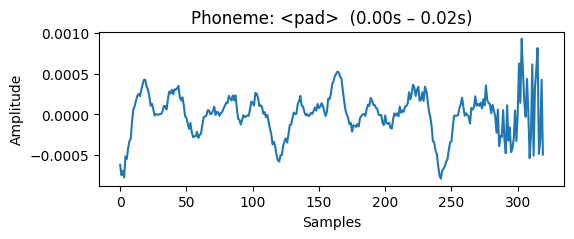

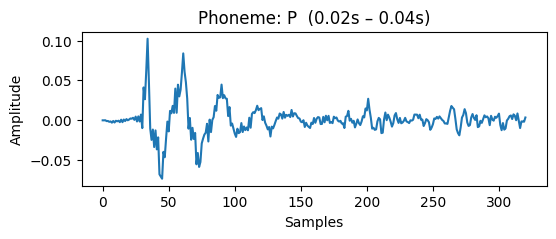

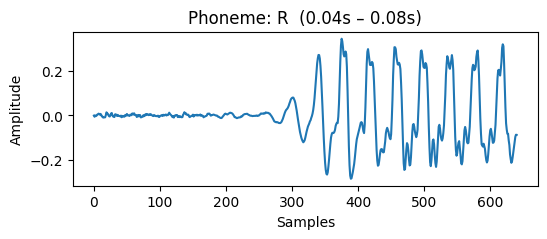

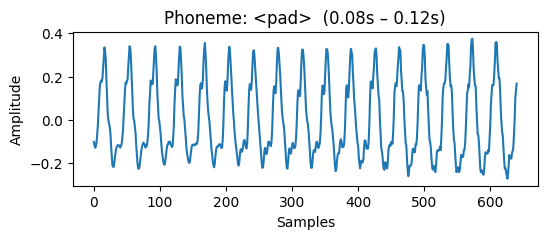

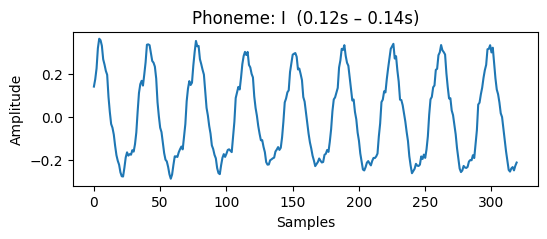

Phoneme: <pad>, Source: Other / approximant sound
Phoneme: P, Source: Plosive (burst of air, vocal tract closure)
Phoneme: R, Source: Other / approximant sound
Phoneme: <pad>, Source: Other / approximant sound
Phoneme: I, Source: Other / approximant sound


In [ ]:
# 1. Load and preprocess audio (mono + resample to 16kHz)
import librosa
import numpy as np
import torch
import matplotlib.pyplot as plt
import soundfile as sf

from transformers import Wav2Vec2Processor, Wav2Vec2ForCTC

audio_path = "/content/drive/MyDrive/Speech processing/LJ001-0001.wav"

# Load audio
audio, sr = librosa.load(audio_path, sr=None, mono=True)

# Resample to 16kHz if needed
target_sr = 16000
if sr != target_sr:
    audio = librosa.resample(audio, orig_sr=sr, target_sr=target_sr)
    sr = target_sr

# 2. Load pre-trained Wav2Vec2 model
processor = Wav2Vec2Processor.from_pretrained("facebook/wav2vec2-base-960h")
model = Wav2Vec2ForCTC.from_pretrained("facebook/wav2vec2-base-960h")

# 3. Phoneme recognition (CTC-based)
inputs = processor(audio, sampling_rate=sr, return_tensors="pt", padding=True)

with torch.no_grad():
    logits = model(inputs.input_values).logits

predicted_ids = torch.argmax(logits, dim=-1)
tokens = processor.tokenizer.convert_ids_to_tokens(predicted_ids[0])

# 4. Estimate phoneme time intervals
time_per_step = audio.shape[0] / logits.shape[1] / sr

phonemes = []
start = 0
prev = tokens[0]

for i, tok in enumerate(tokens):
    if tok != prev:
        end = i
        if prev != "|":  # ignore silence token
            phonemes.append((prev, start * time_per_step, end * time_per_step))
        start = i
        prev = tok

# Add last phoneme
end = len(tokens)
if prev != "|":
    phonemes.append((prev, start * time_per_step, end * time_per_step))

# 5–6. Extract, save, and visualize phoneme segments
output_segments = []

for idx, (ph, t_start, t_end) in enumerate(phonemes[:5]):  # first 5 phonemes
    s = int(t_start * sr)
    e = int(t_end * sr)
    segment = audio[s:e]

    # Save phoneme audio
    out_path = f"phoneme_{idx}_{ph}.wav"
    sf.write(out_path, segment, sr)
    output_segments.append(out_path)

    # Visualize waveform
    plt.figure(figsize=(6, 2))
    plt.plot(segment)
    plt.title(f"Phoneme: {ph}  ({t_start:.2f}s – {t_end:.2f}s)")
    plt.xlabel("Samples")
    plt.ylabel("Amplitude")
    plt.show()

# 7. Infer sound source nature (rule-based)
def infer_source(phoneme):
    if phoneme in ["P", "B", "T", "D", "K", "G"]:
        return "Plosive (burst of air, vocal tract closure)"
    elif phoneme in ["S", "Z", "F", "V", "SH"]:
        return "Fricative (turbulent airflow)"
    elif phoneme in ["M", "N", "NG"]:
        return "Nasal (airflow through nasal cavity)"
    elif phoneme in ["AA", "AE", "AH", "EH", "IH", "IY", "OW", "UH", "UW"]:
        return "Vowel (voiced, open vocal tract)"
    else:
        return "Other / approximant sound"

for ph, t1, t2 in phonemes[:5]:
    print(f"Phoneme: {ph}, Source: {infer_source(ph)}")

# lab 3


/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


preprocessor_config.json:   0%|          | 0.00/159 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/163 [00:00<?, ?B/s]

config.json: 0.00B [00:00, ?B/s]

vocab.json:   0%|          | 0.00/291 [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/85.0 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/378M [00:00<?, ?B/s]

Some weights of Wav2Vec2ForCTC were not initialized from the model checkpoint at facebook/wav2vec2-base-960h and are newly initialized: ['wav2vec2.masked_spec_embed']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


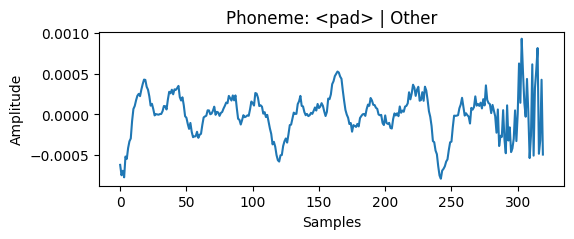

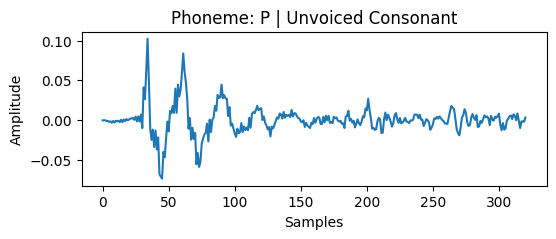

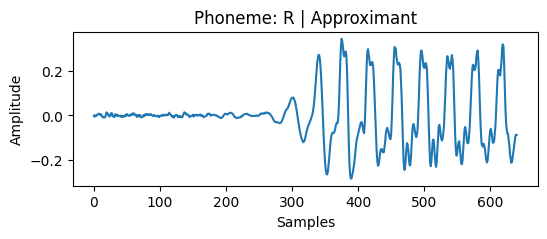

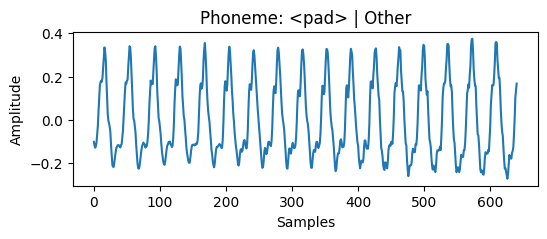

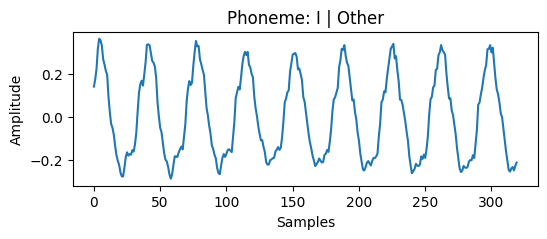

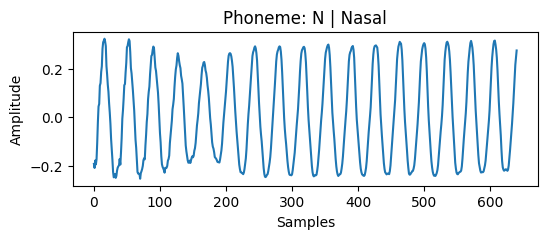

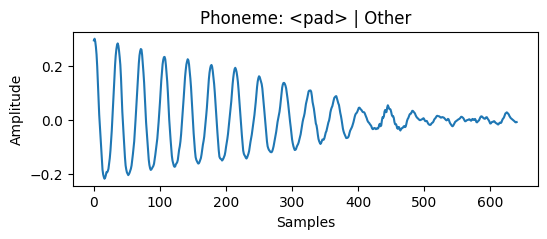

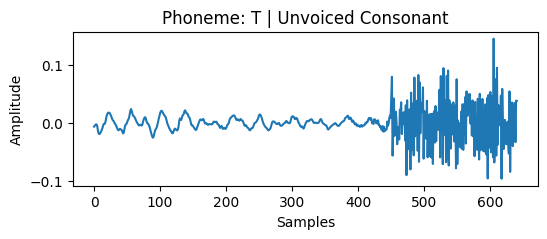

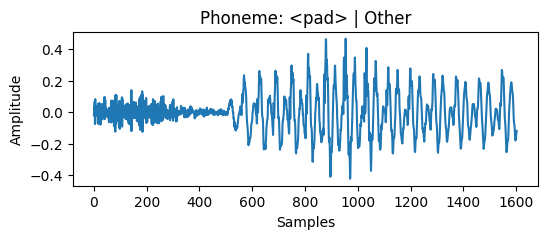

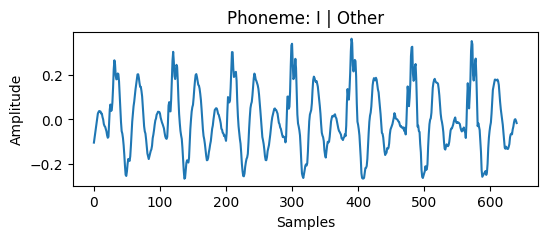

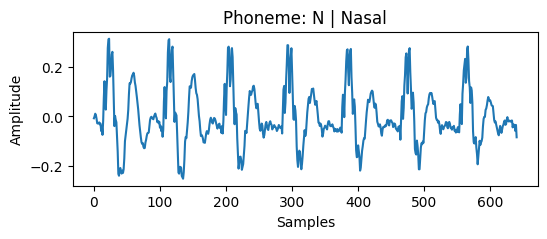

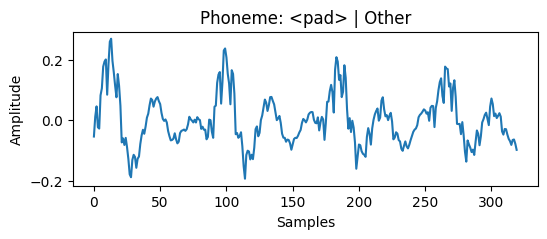

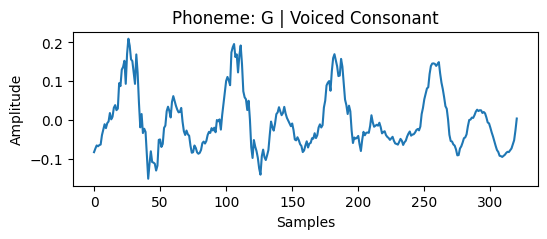

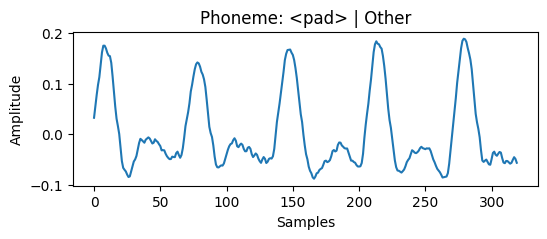

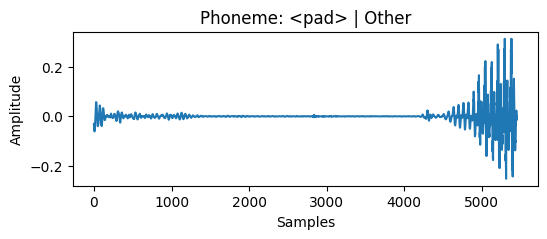

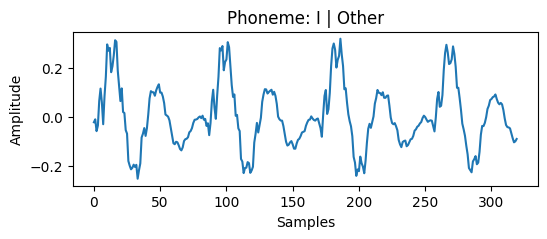

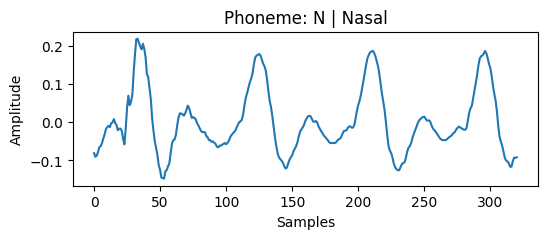

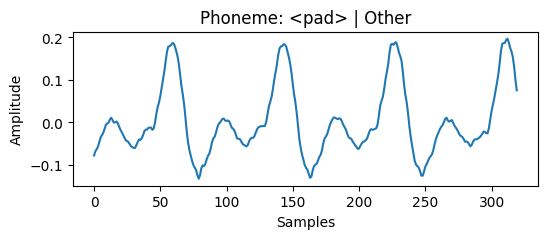

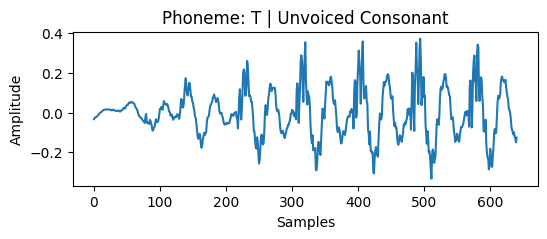

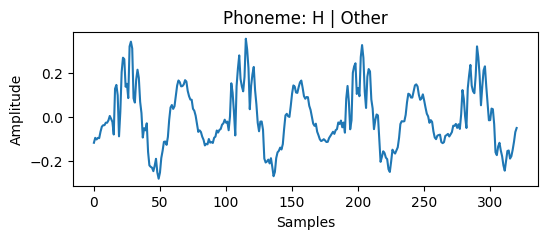

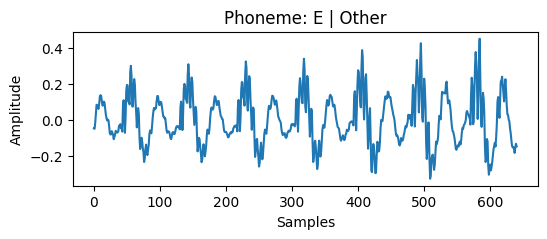

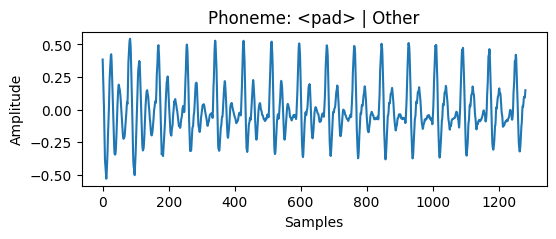

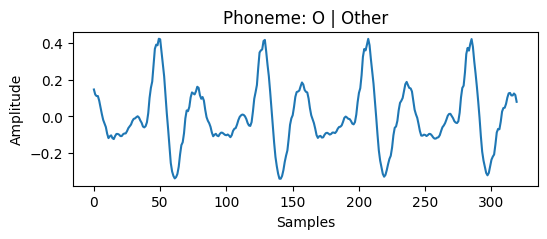

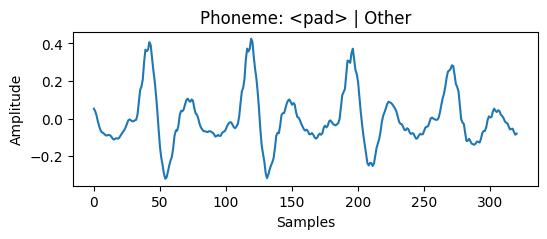

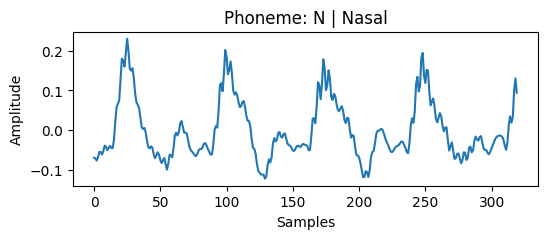

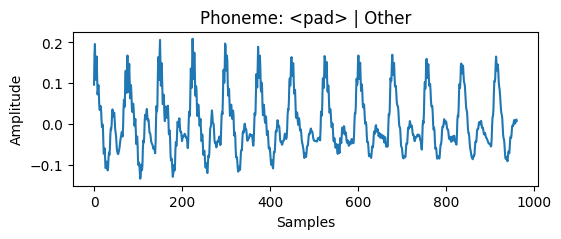

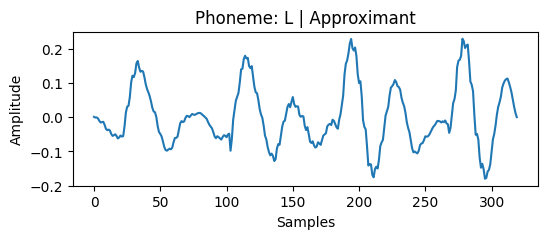

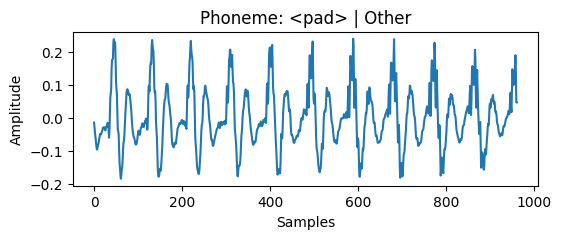

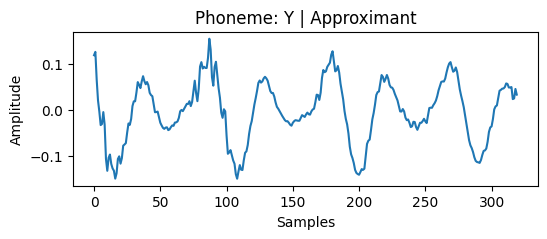

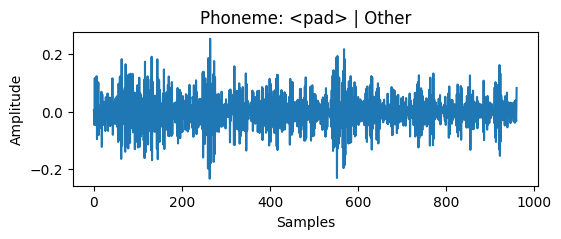

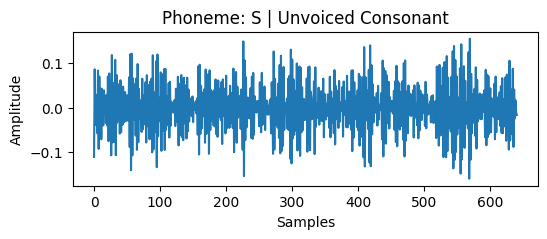

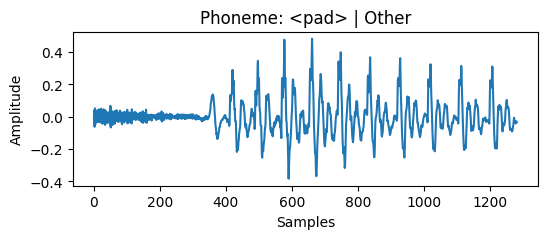

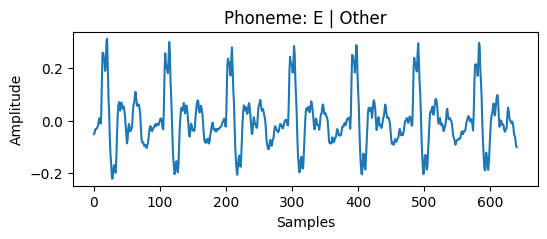

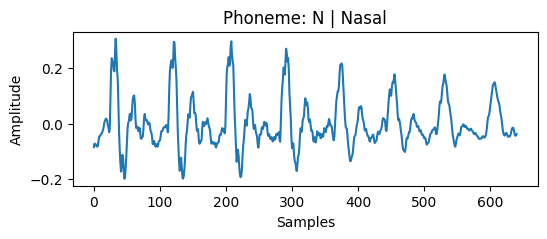

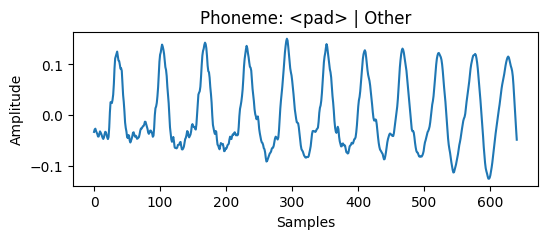

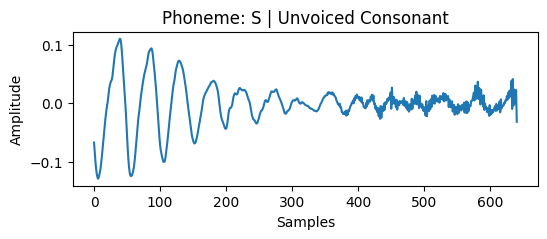

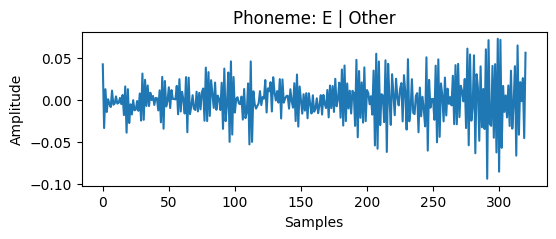

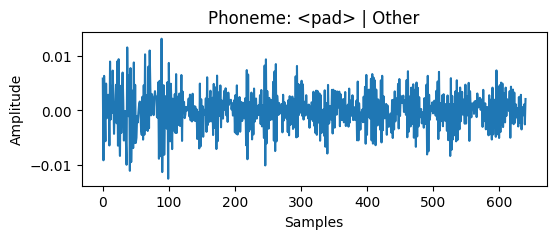

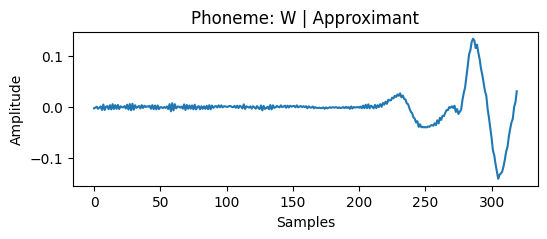

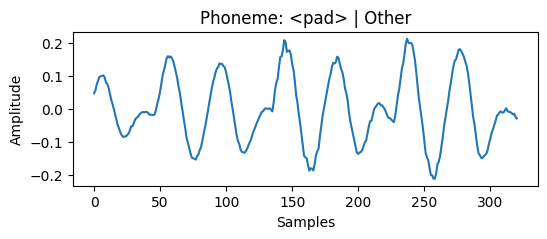

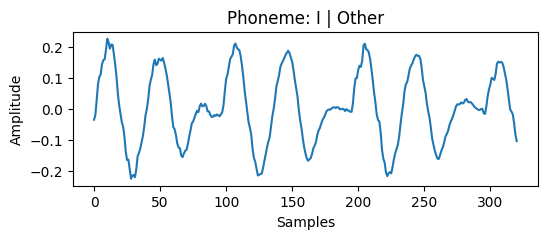

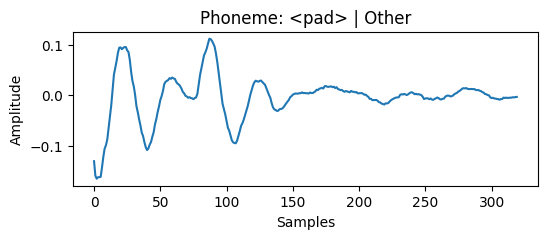

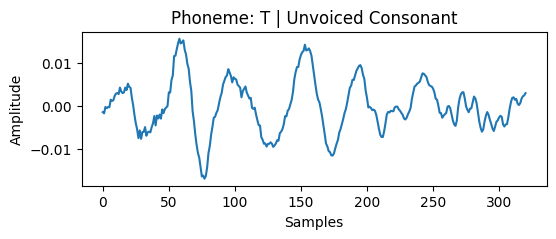

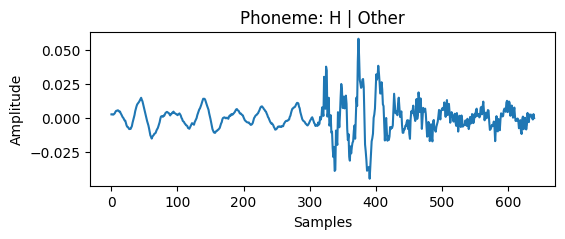

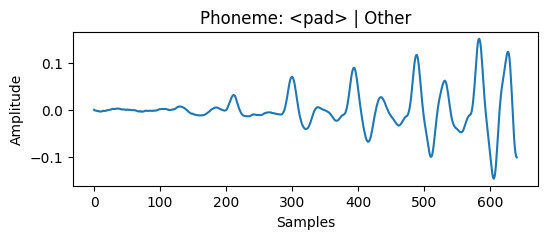

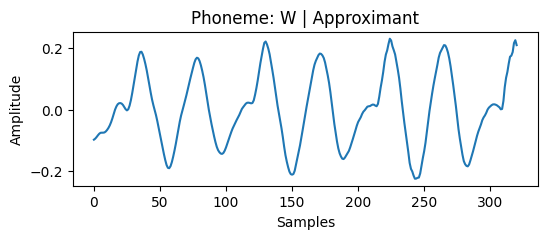

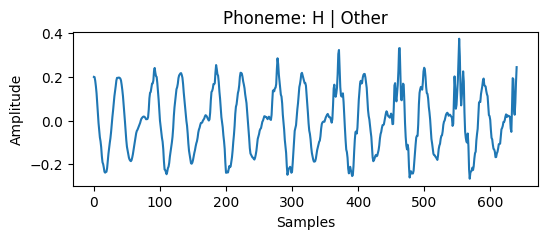

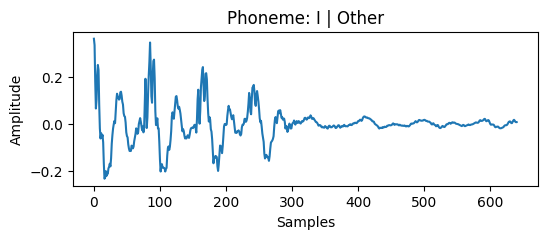

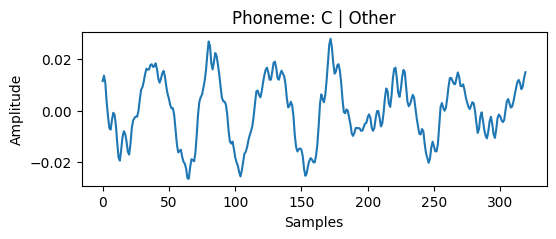

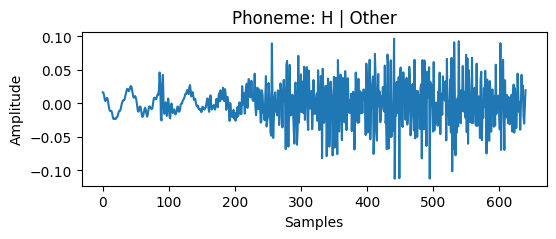

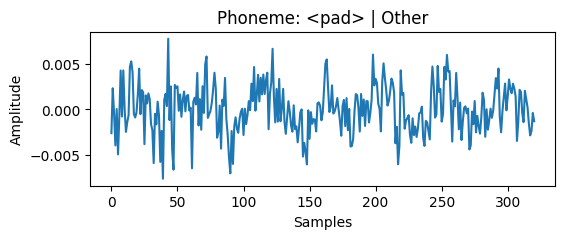

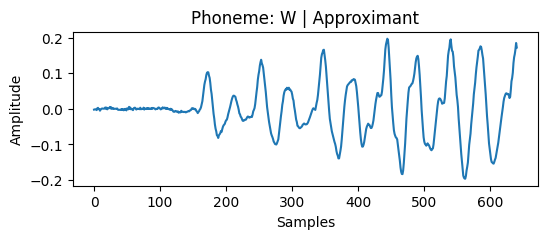

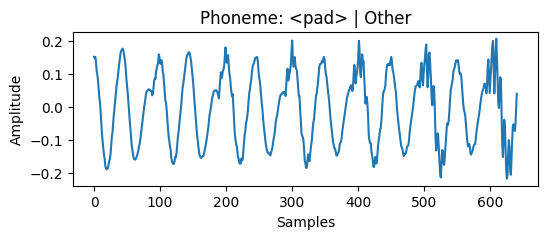

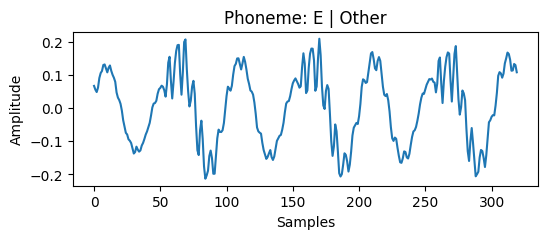

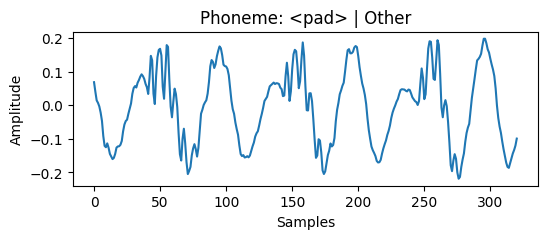

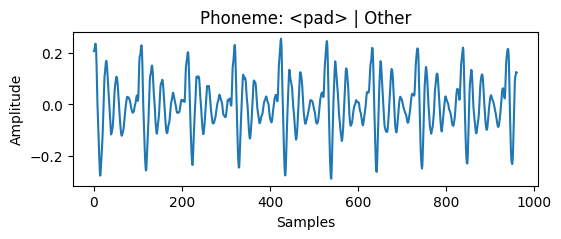

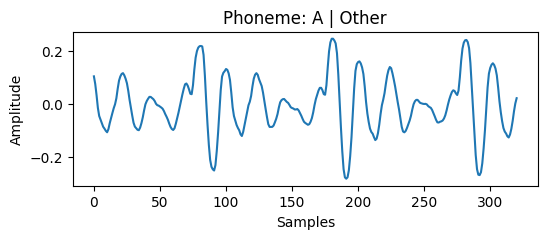

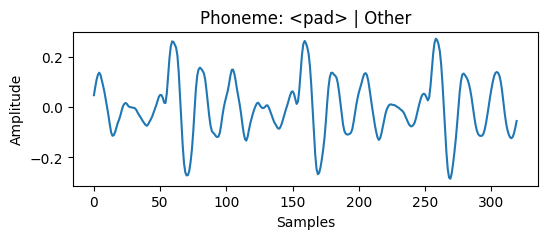

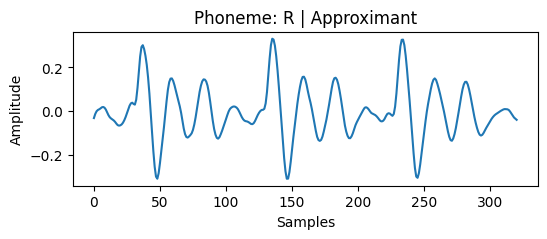

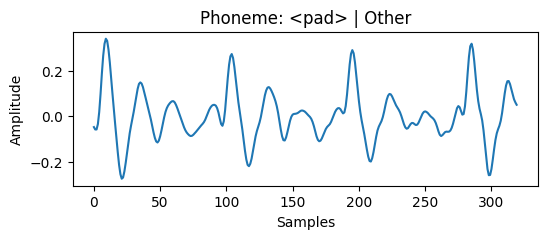

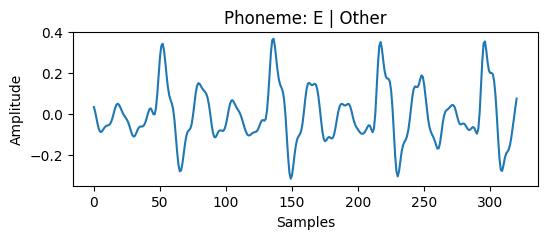

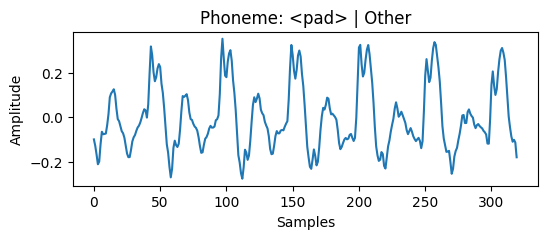

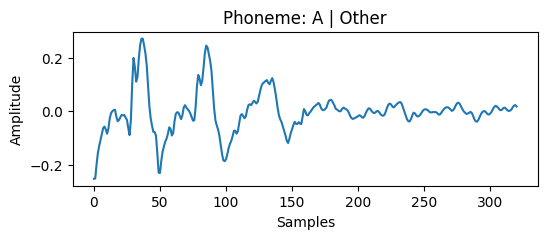

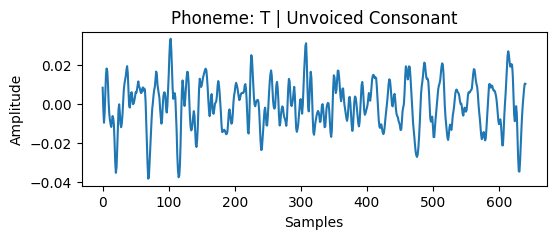

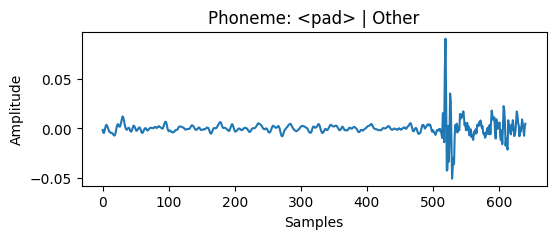

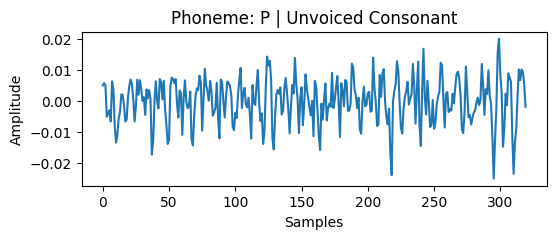

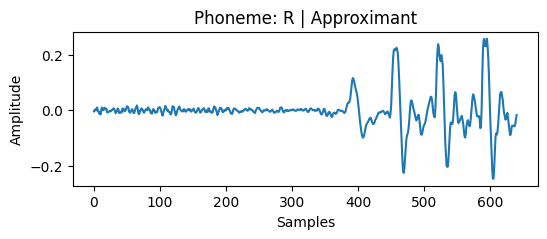

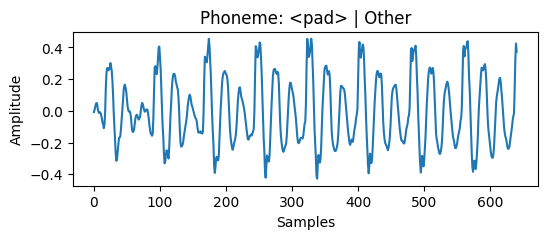

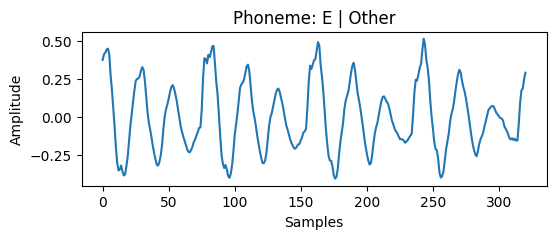

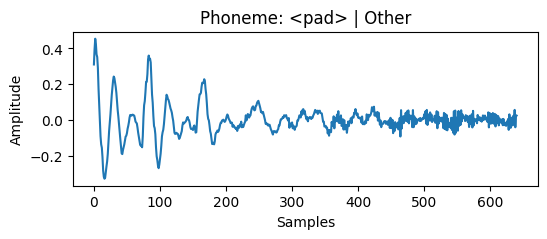

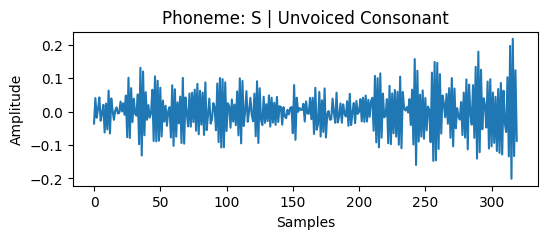

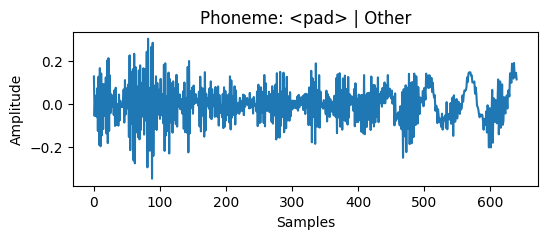

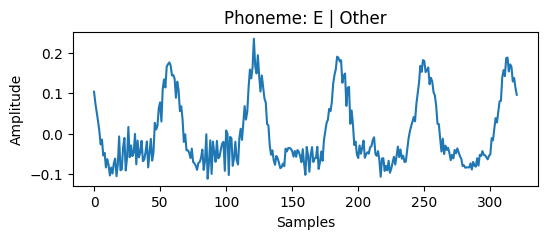

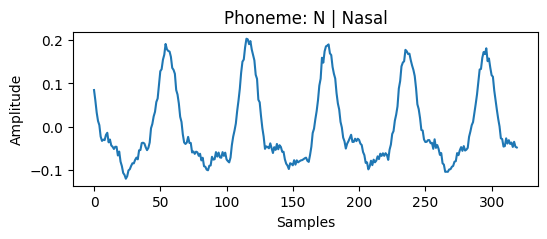

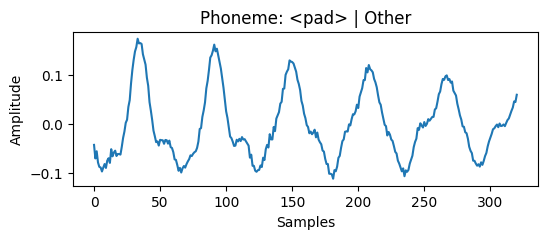

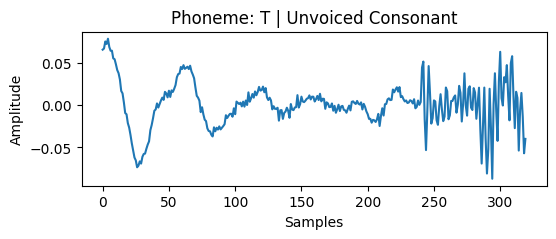

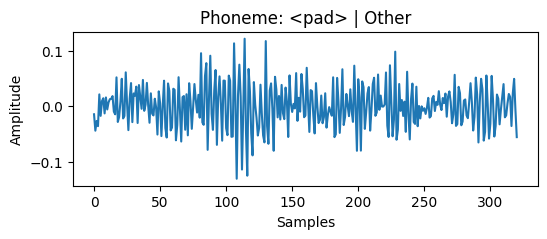

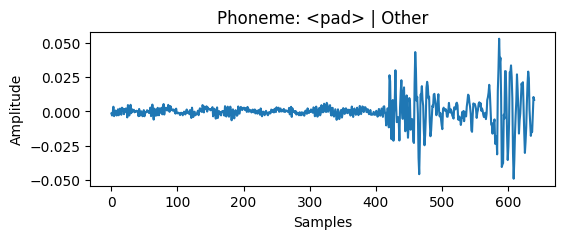

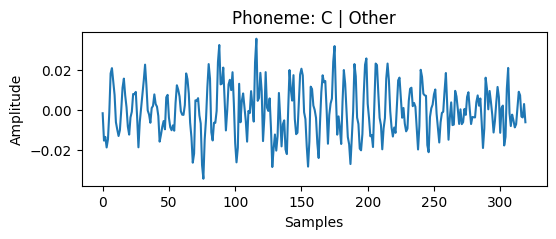

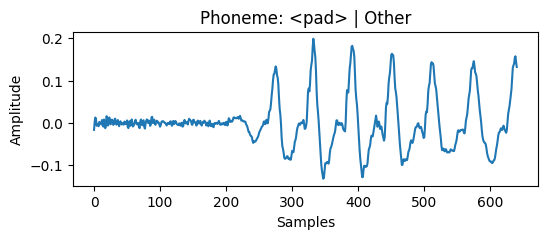

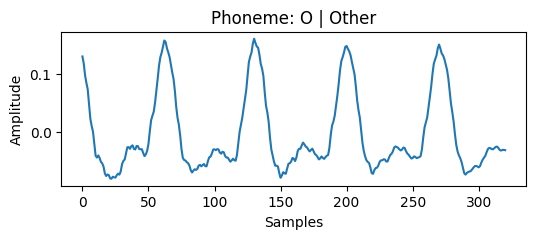

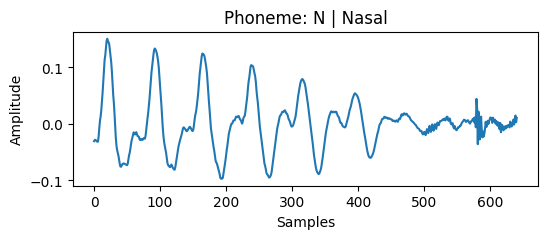

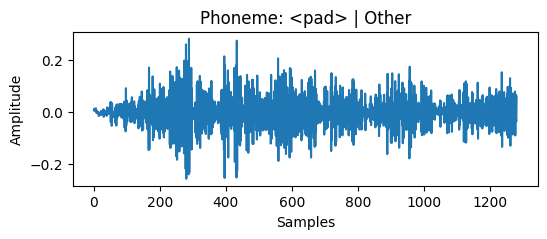

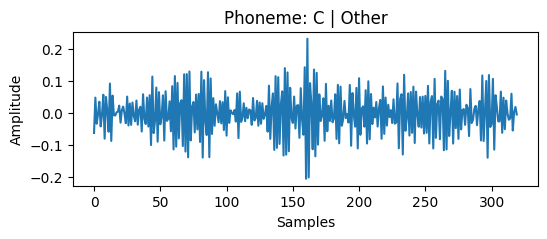

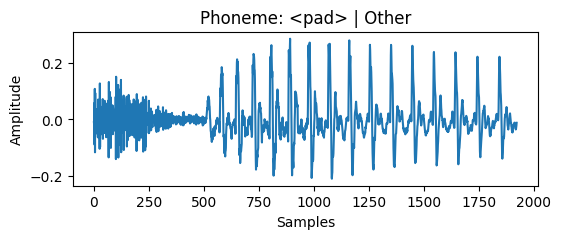

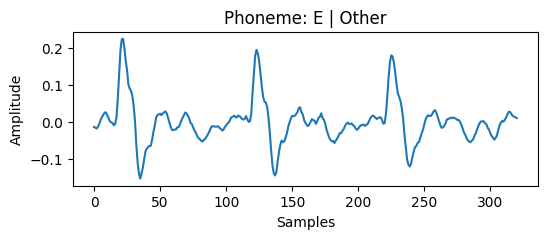

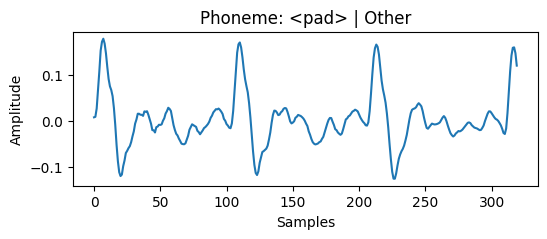

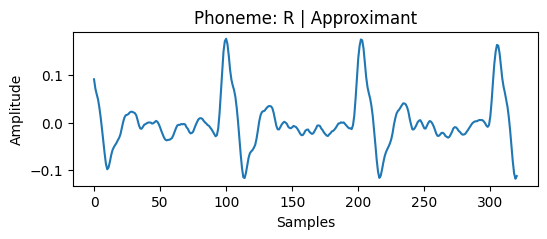

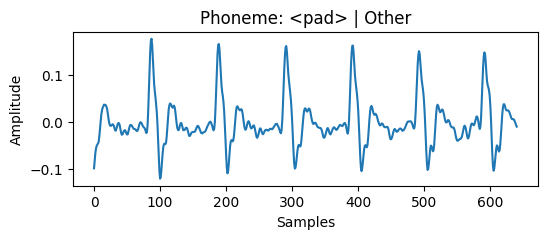

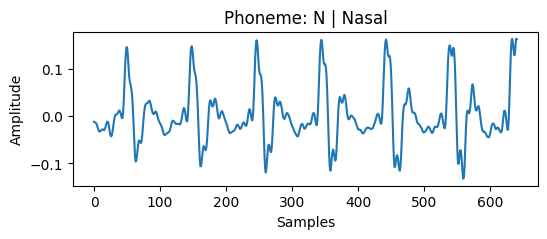

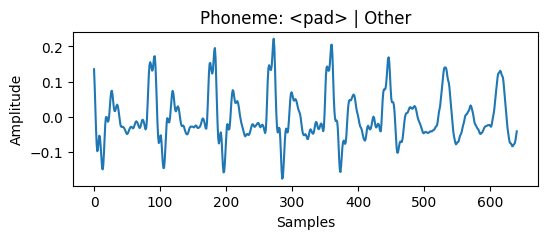

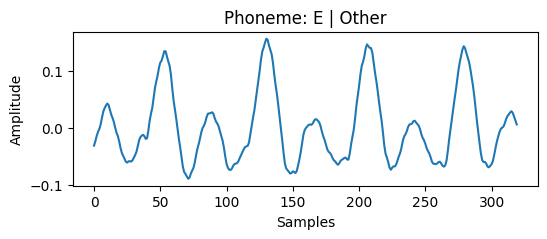

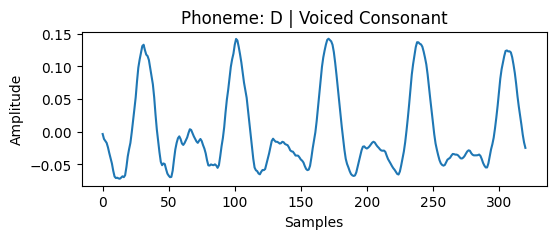

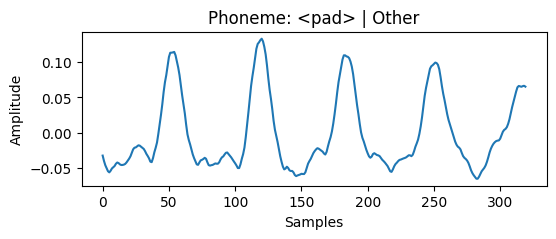

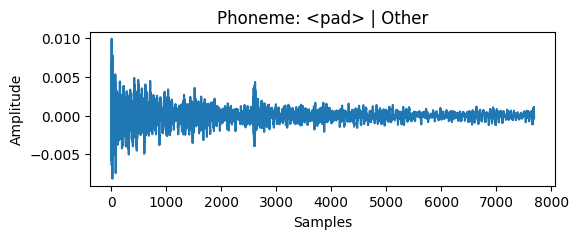

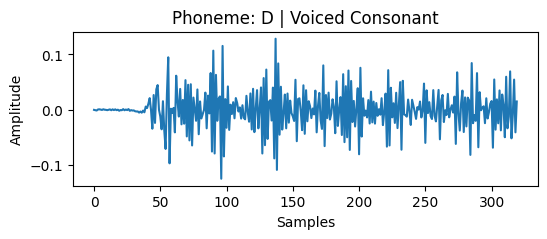

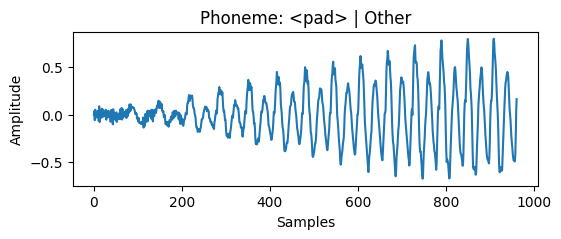

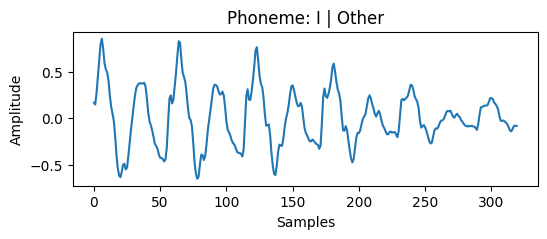

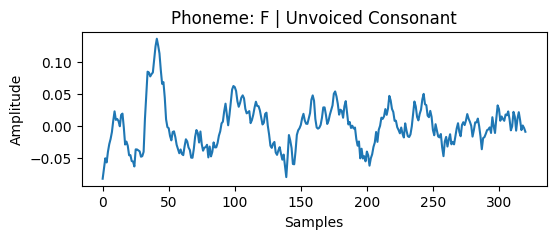

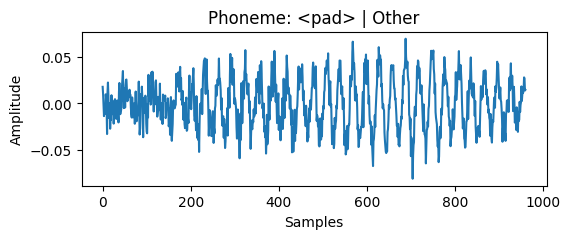

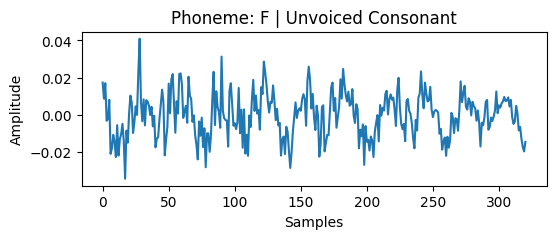

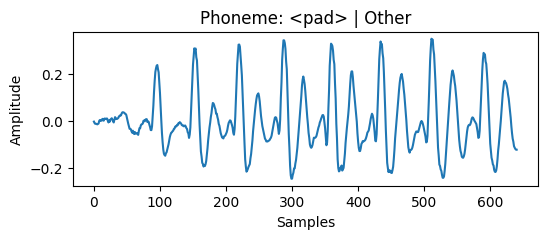

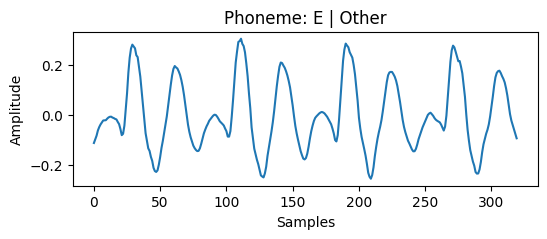

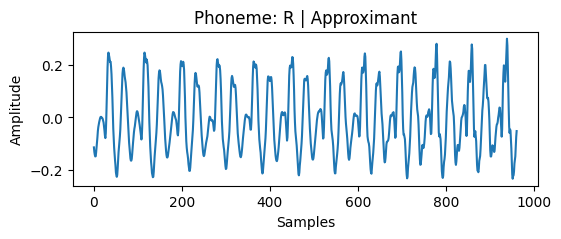

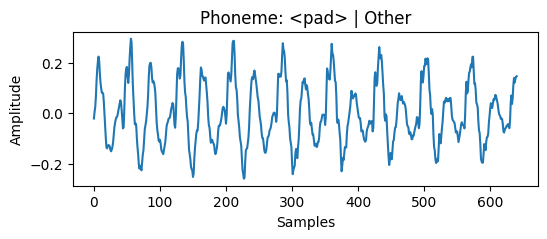

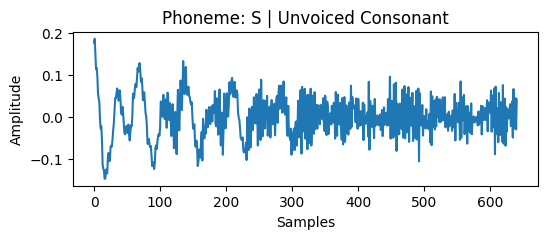

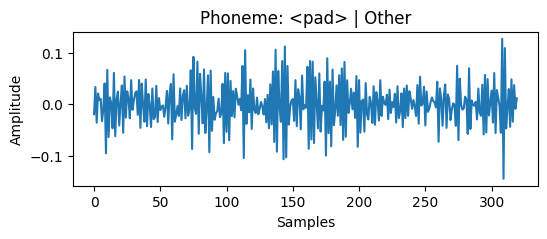

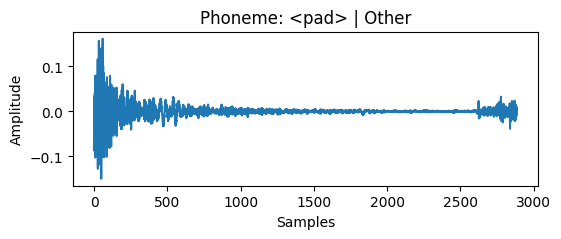

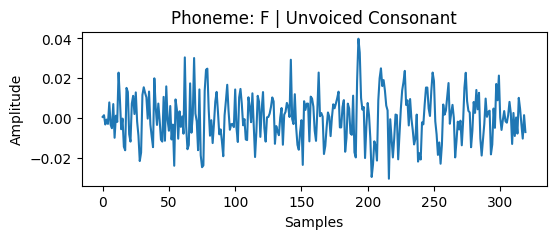

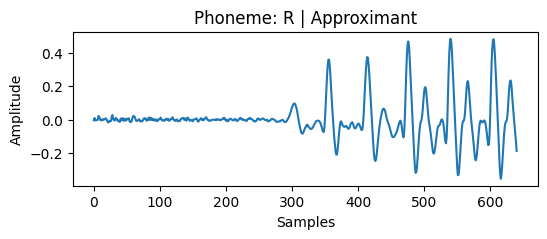

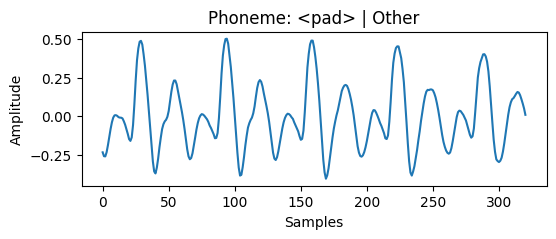

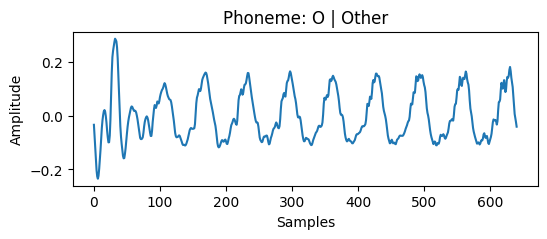

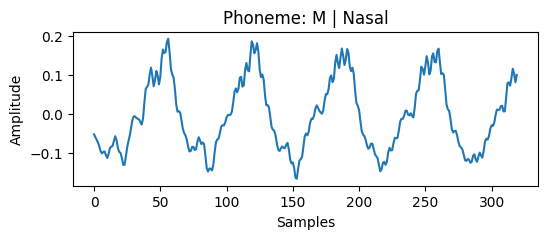

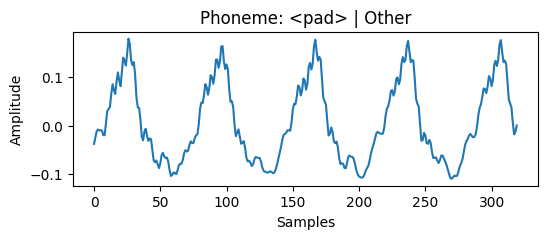

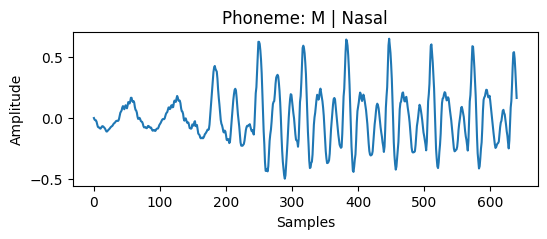

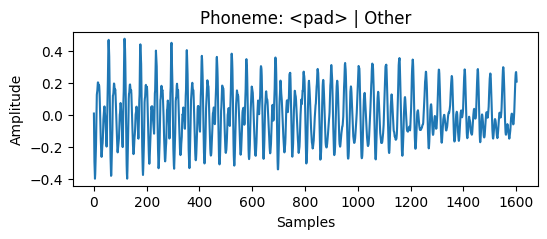

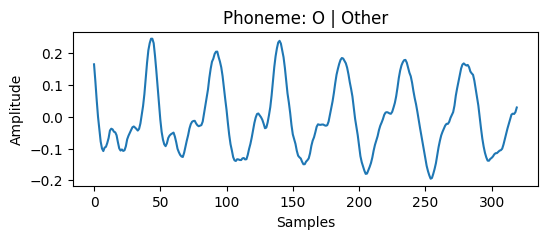

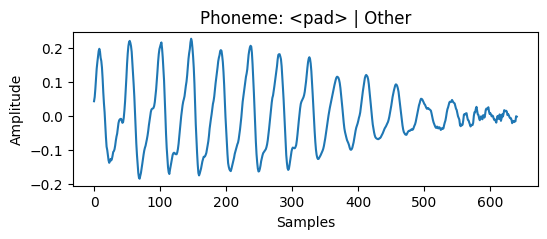

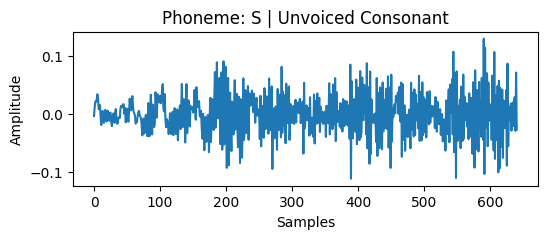

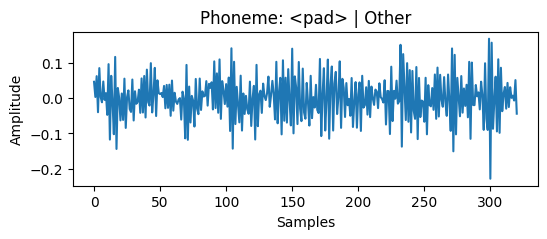

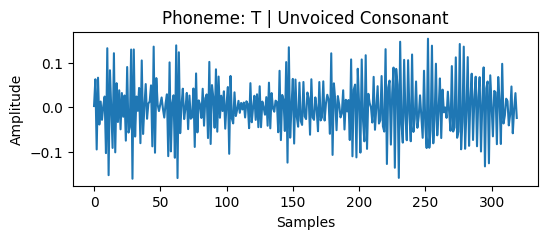

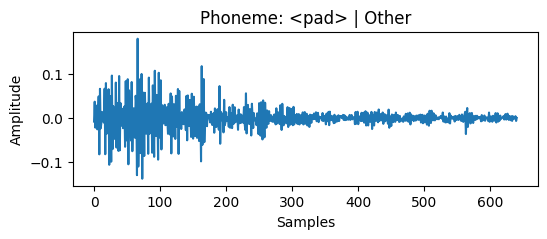

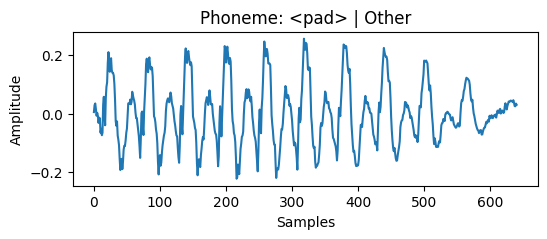

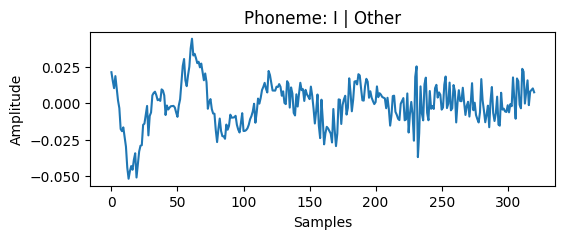

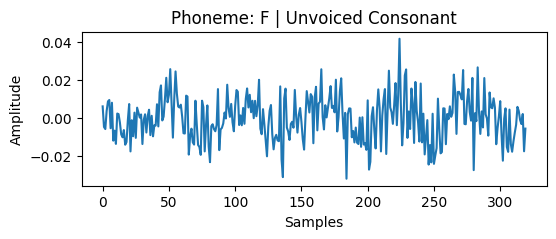

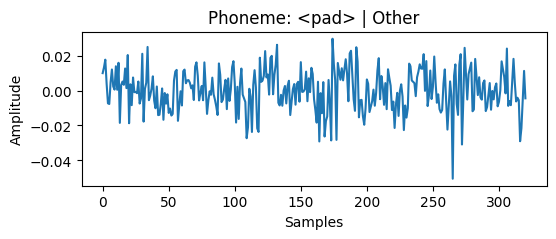

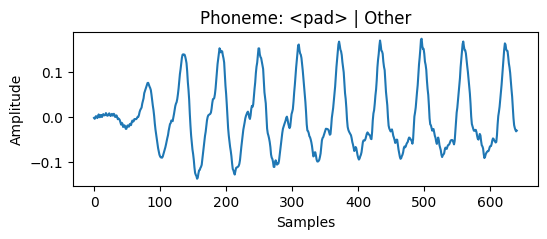

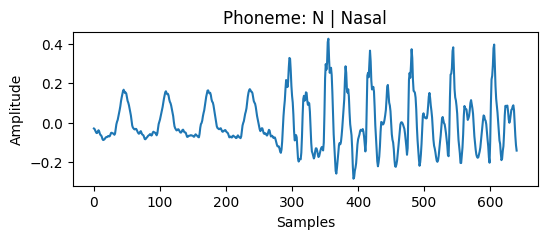

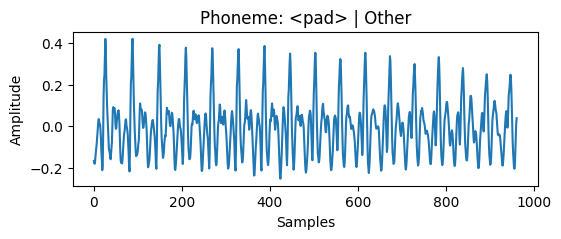

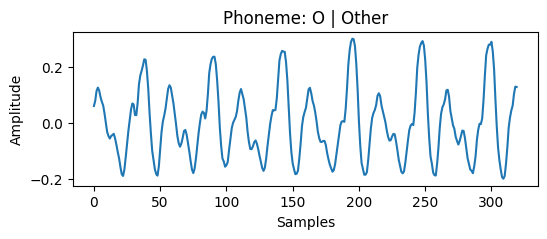

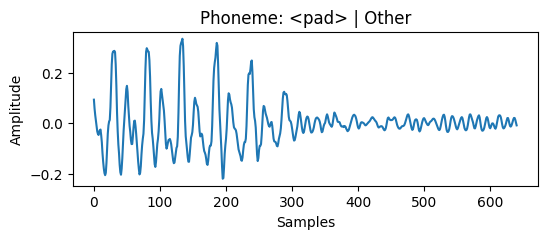

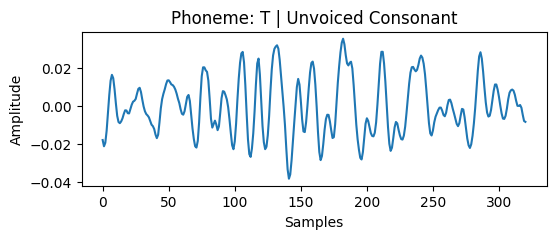

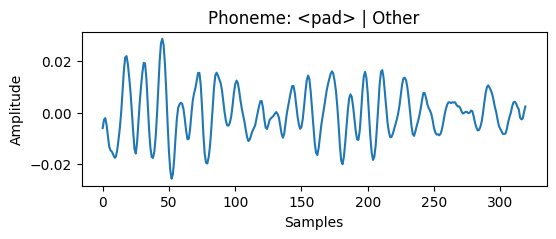

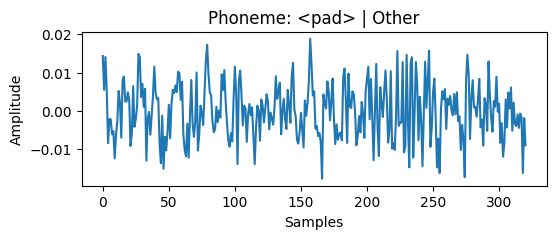

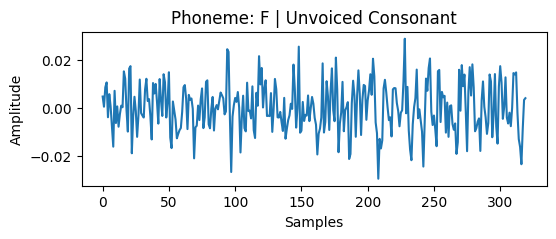

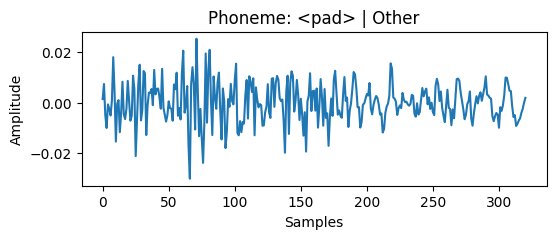

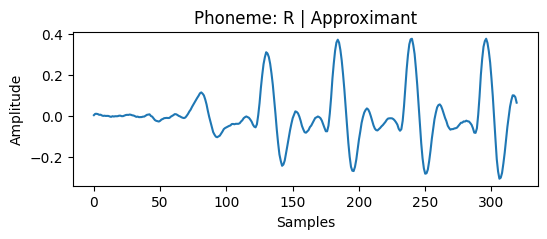

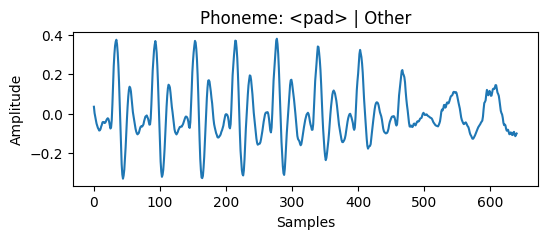

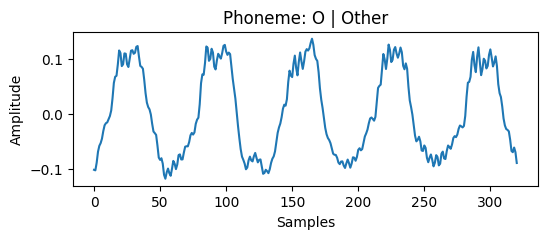

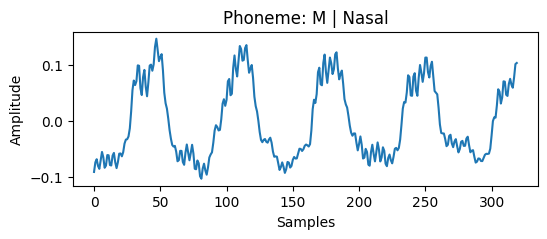

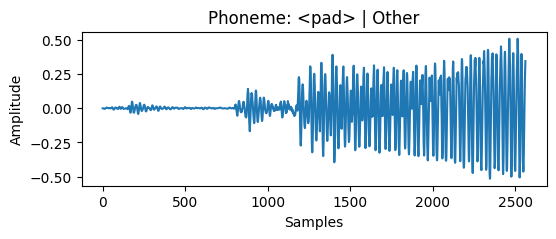

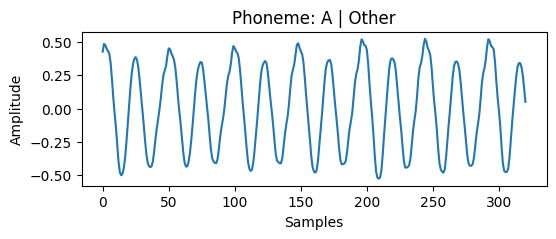

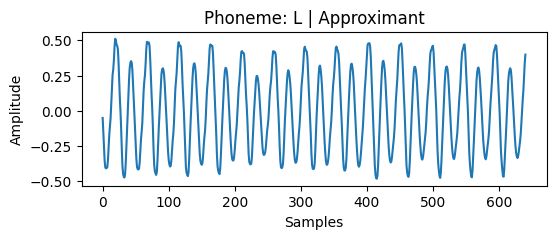

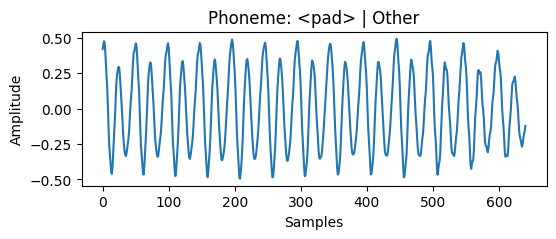

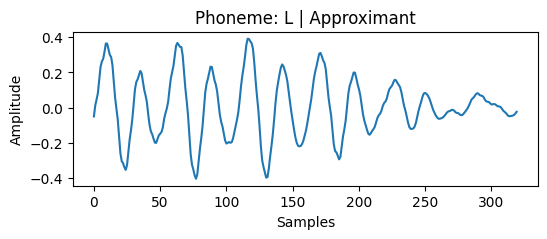

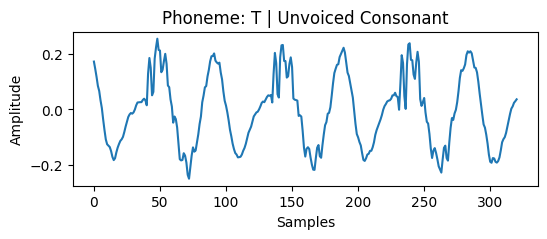

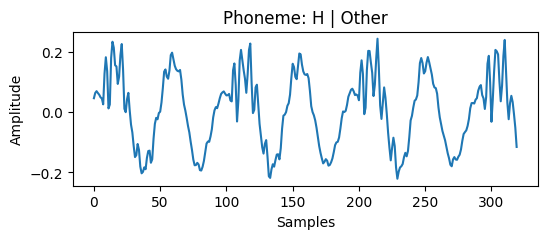

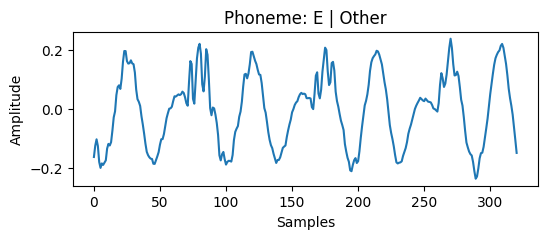

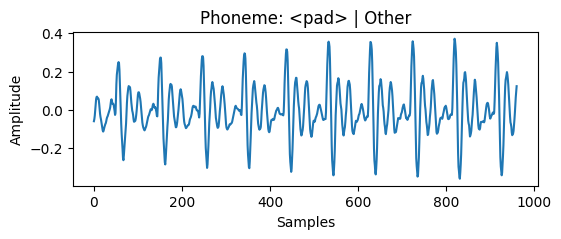

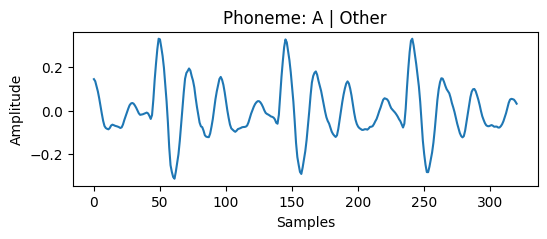

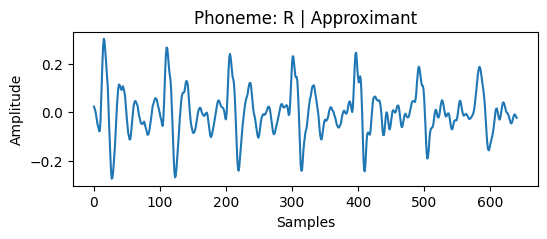

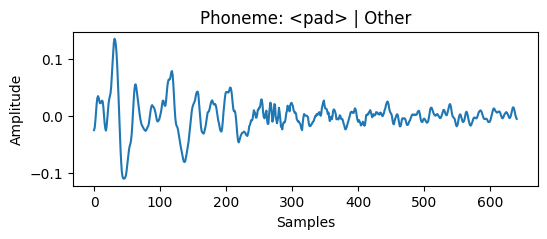

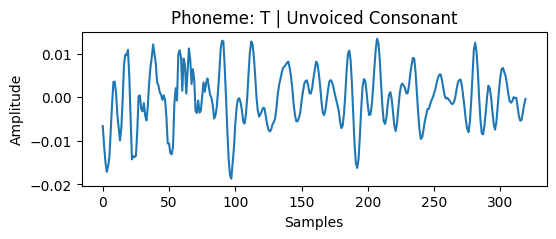

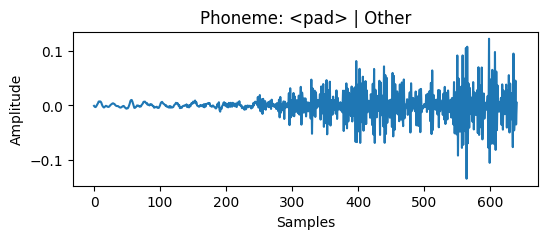

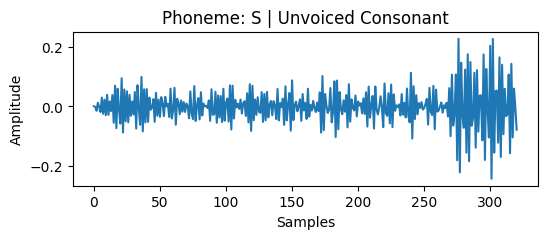

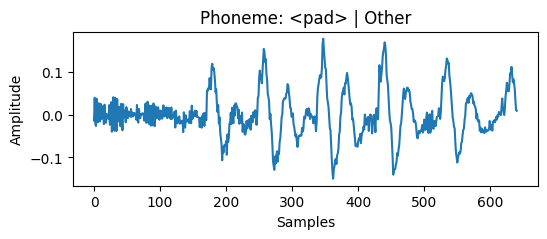

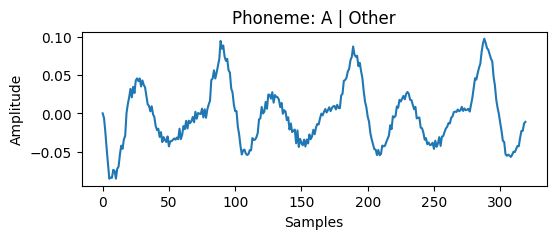

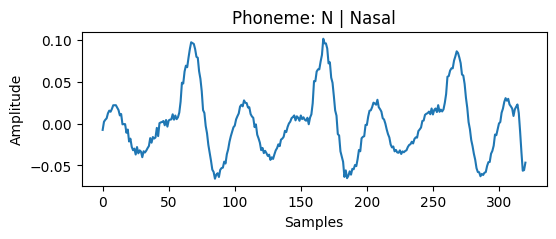

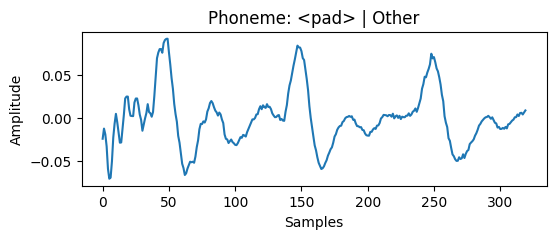

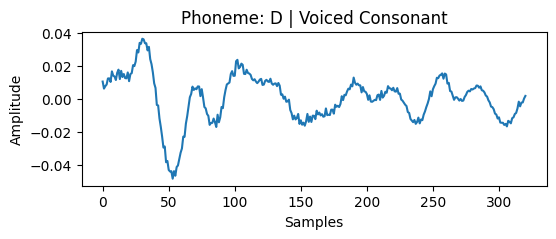

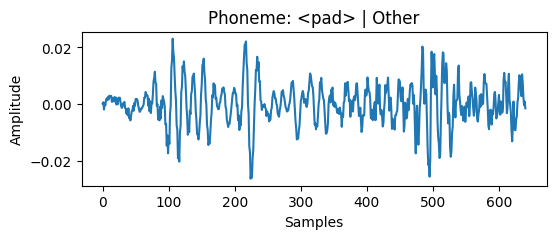

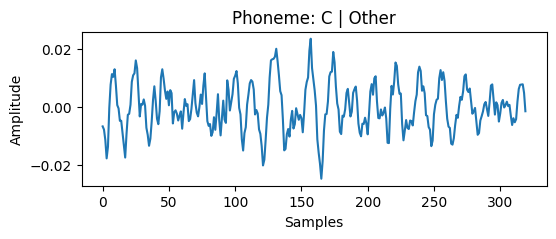

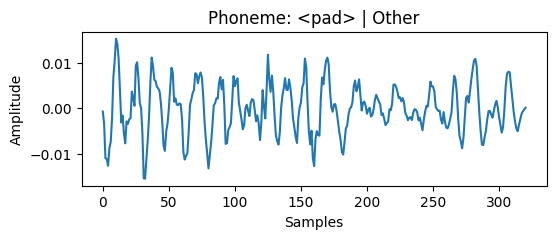

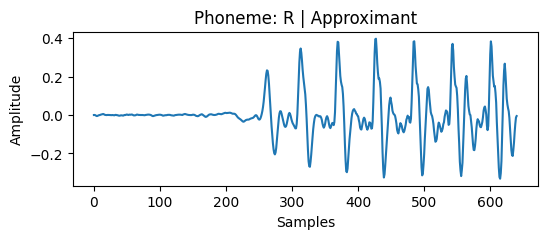

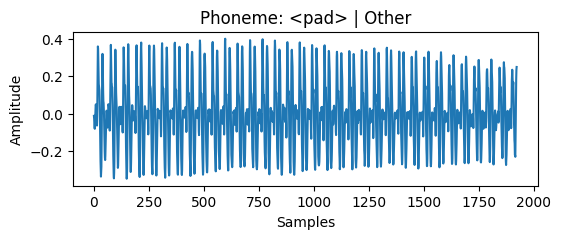

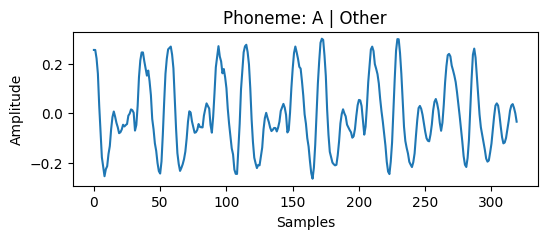

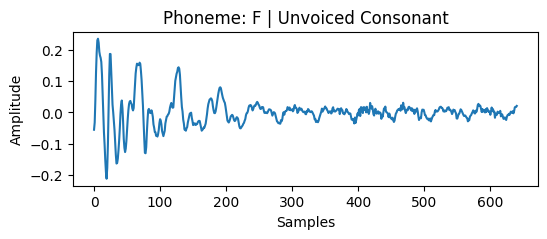

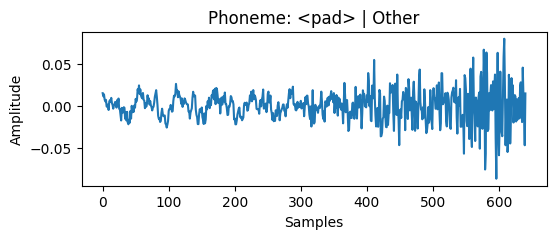

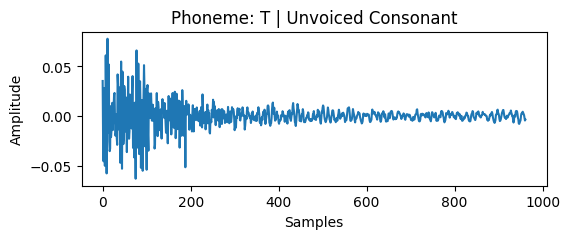

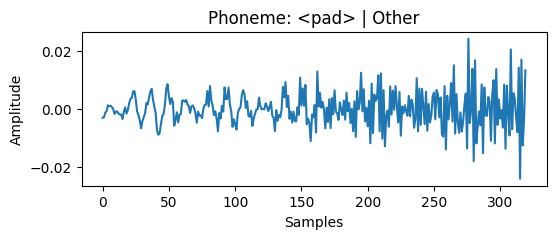

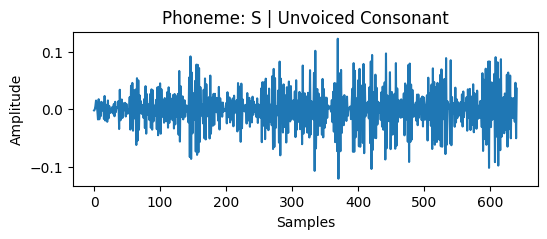

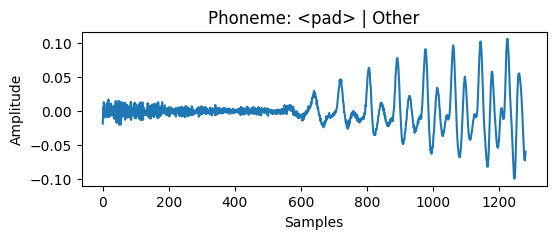

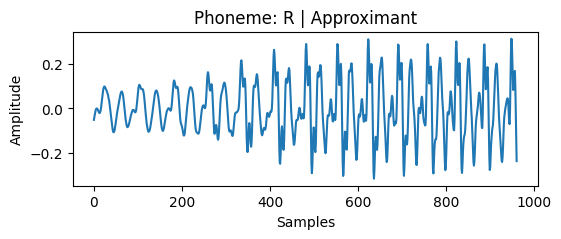

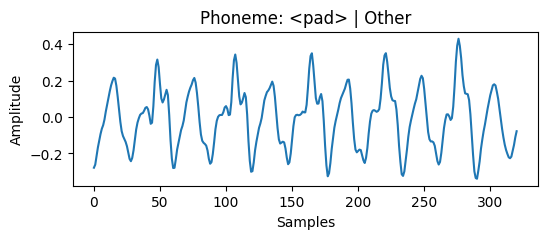

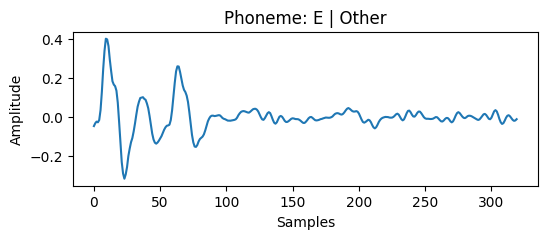

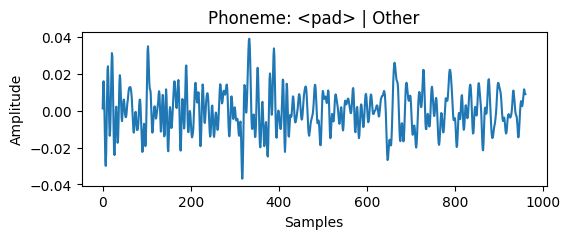

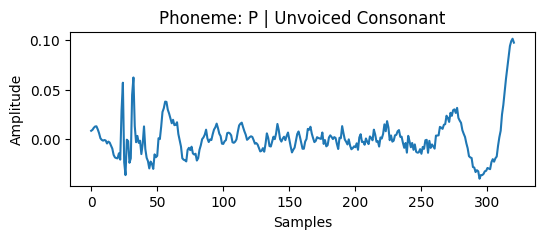

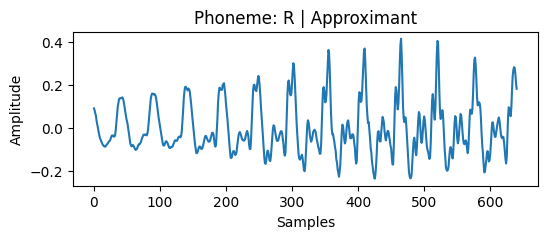

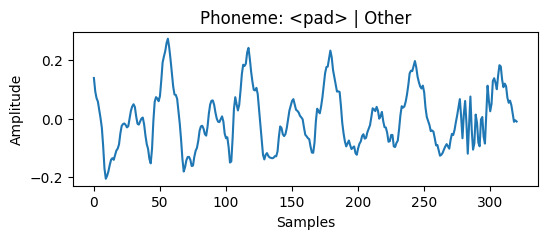

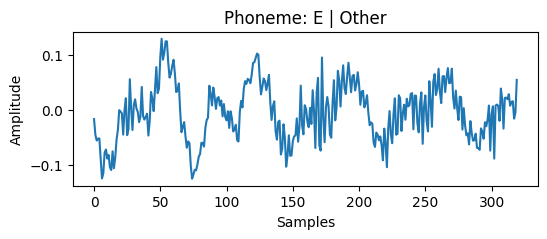

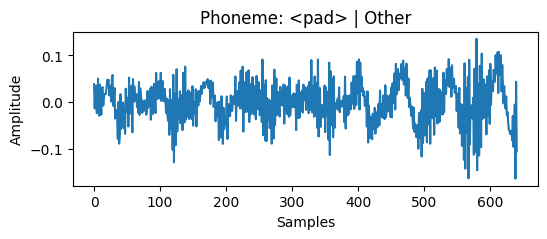

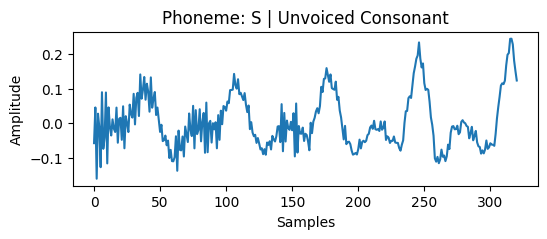

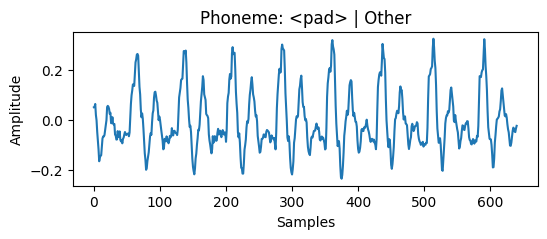

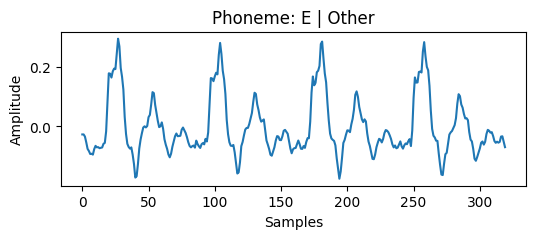

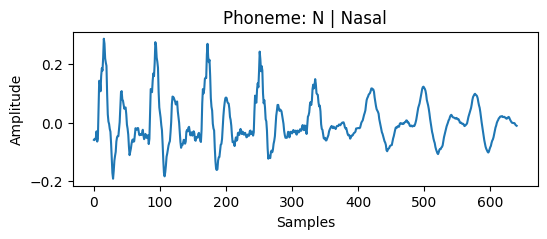

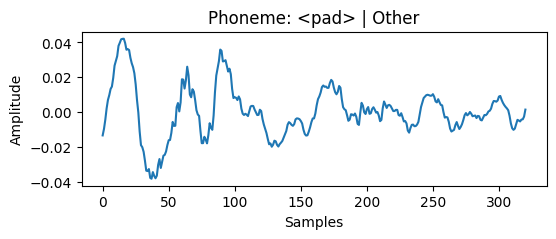

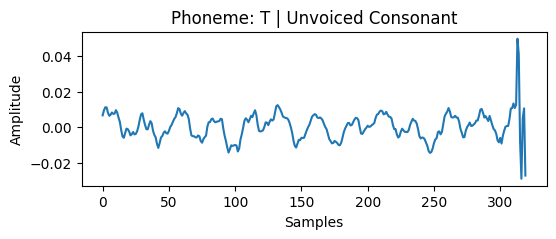

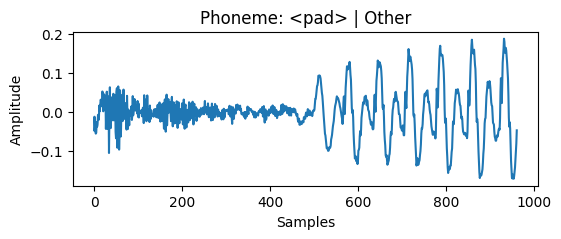

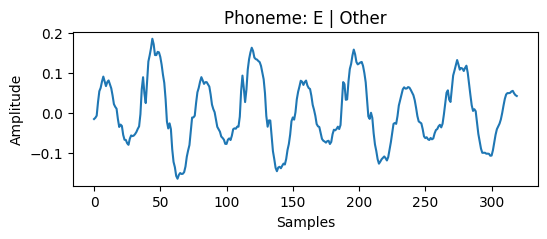

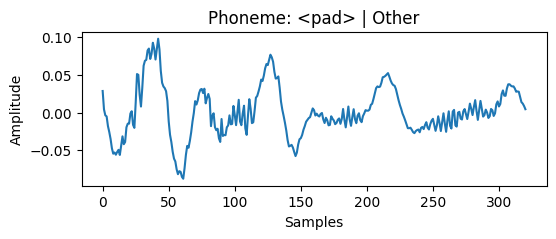

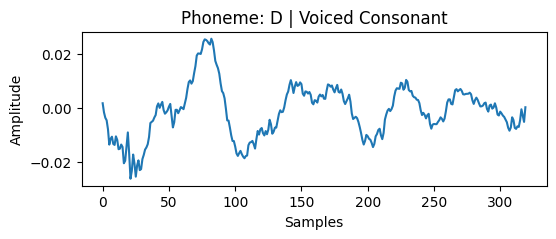

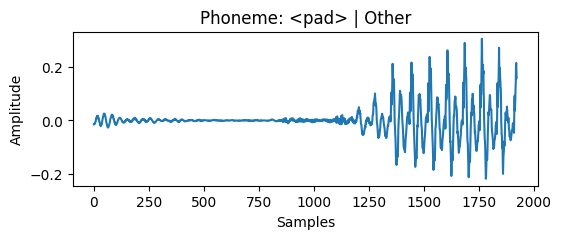

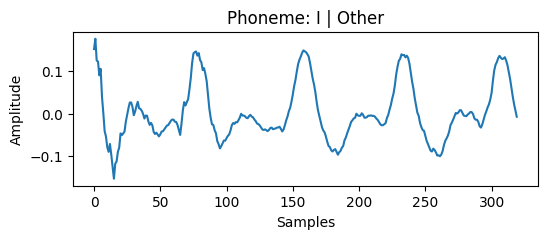

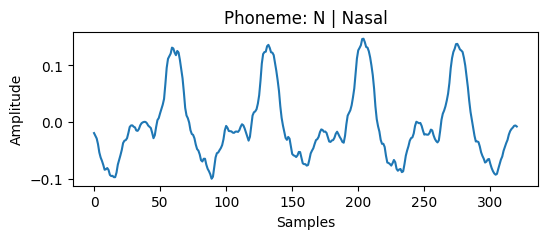

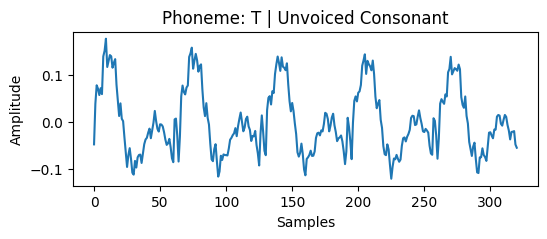

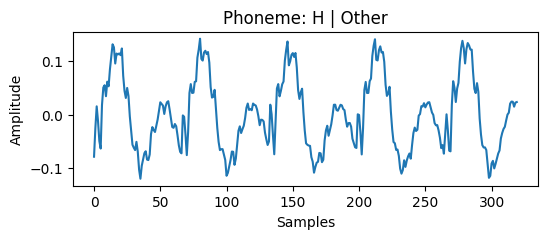

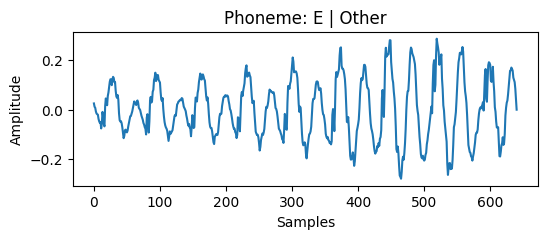

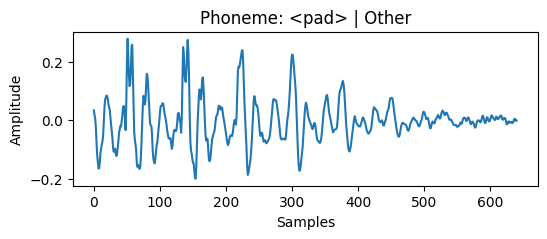

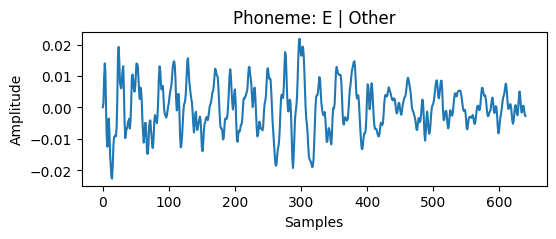

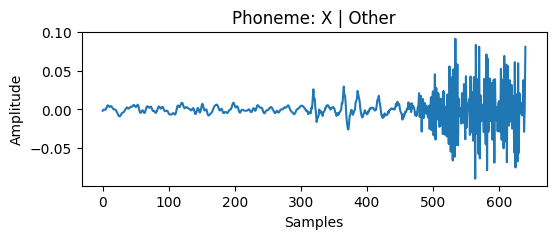

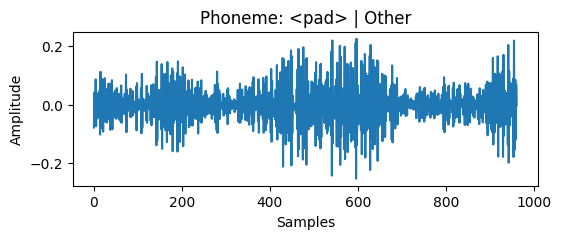

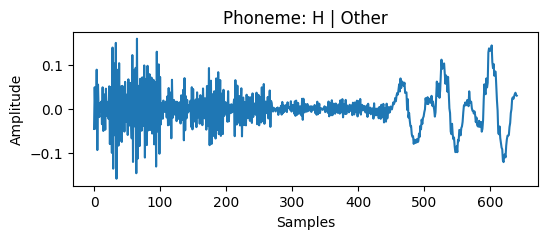

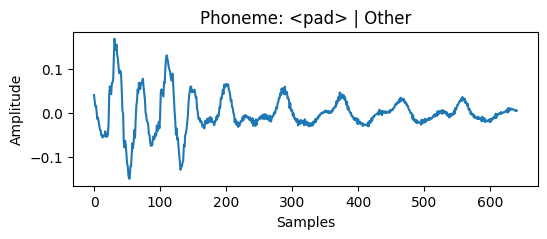

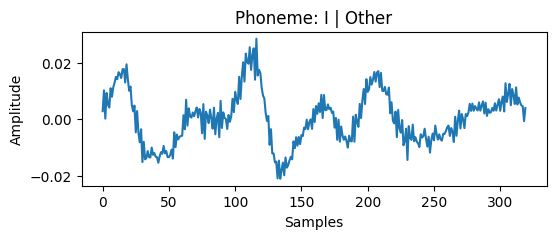

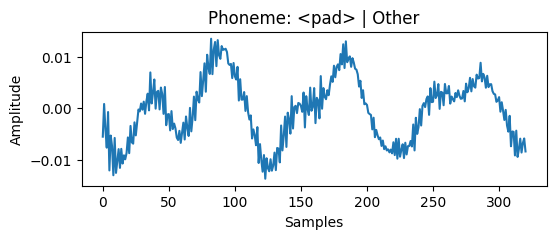

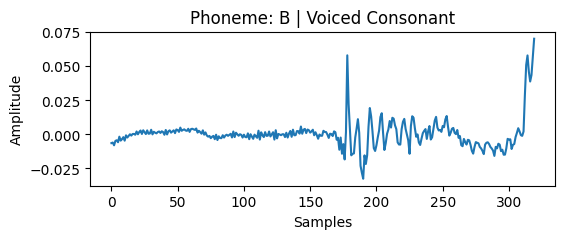

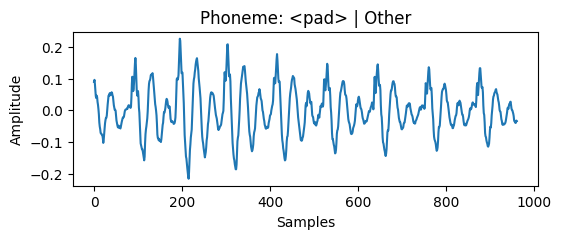

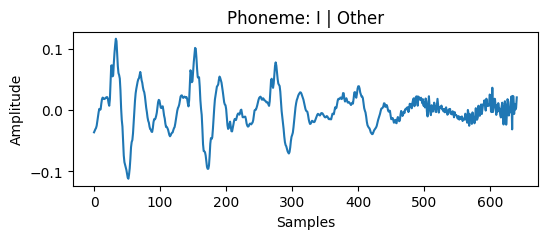

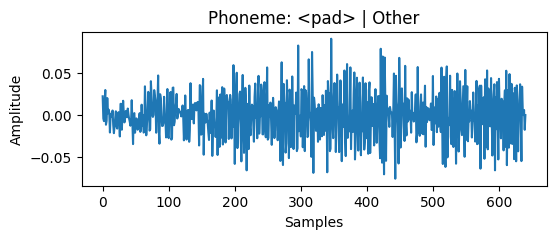

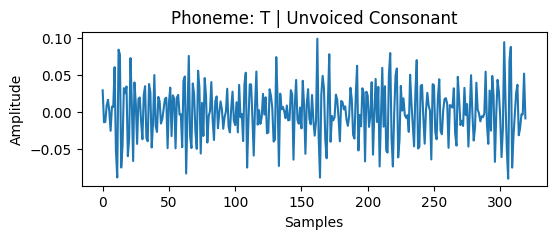

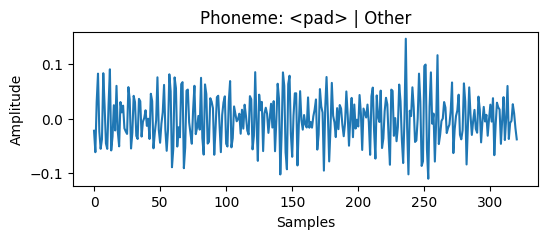

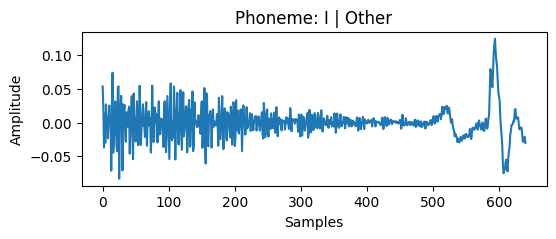

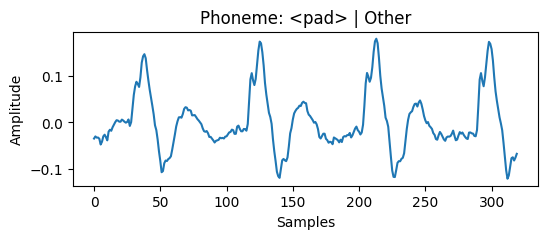

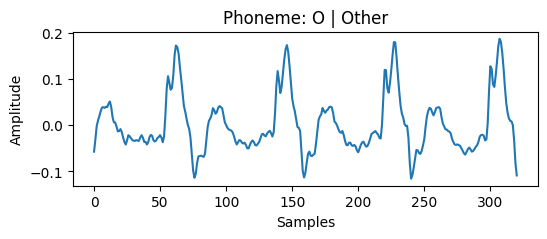

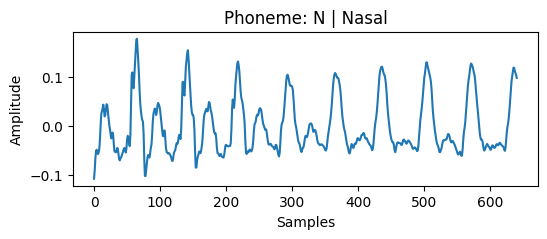

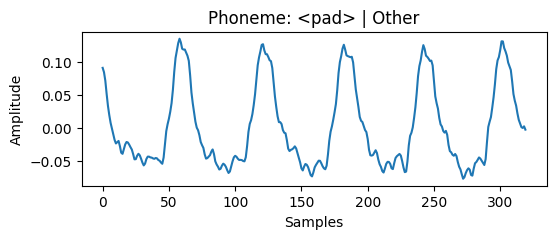

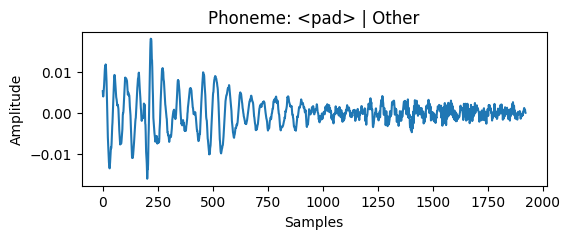

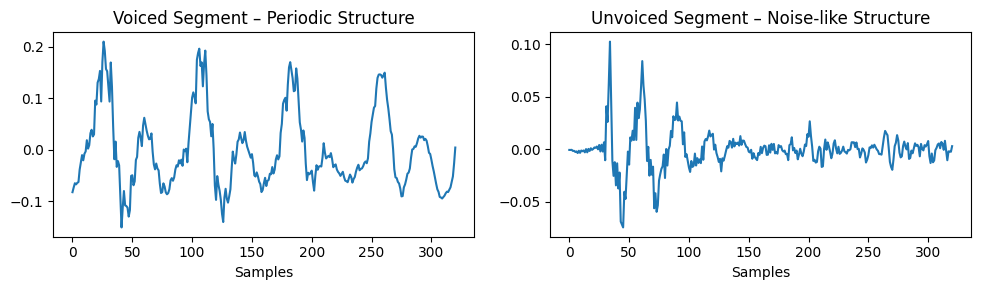

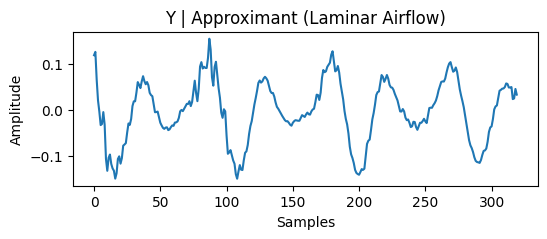

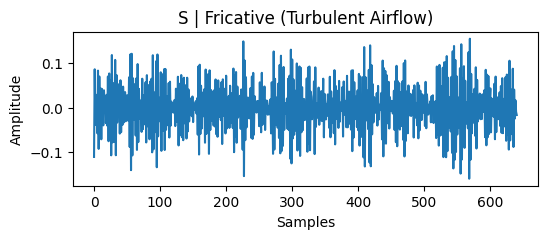

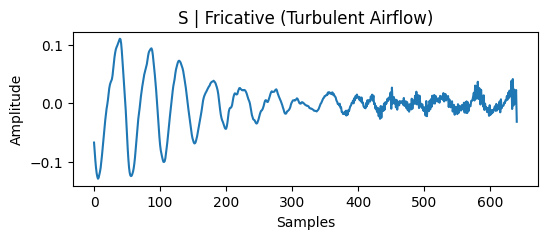

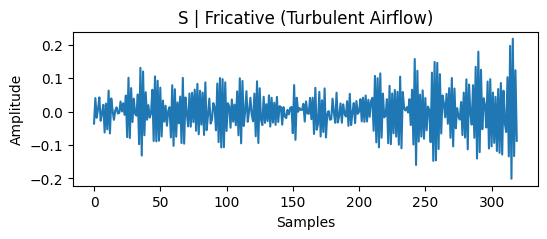

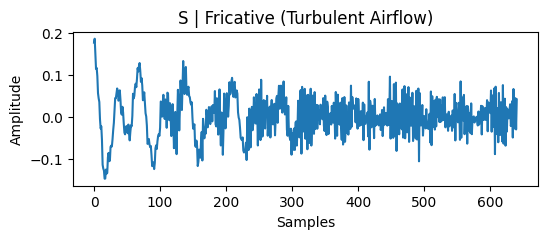

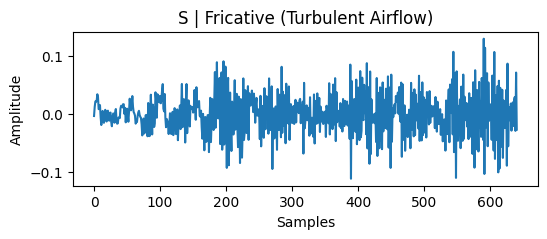

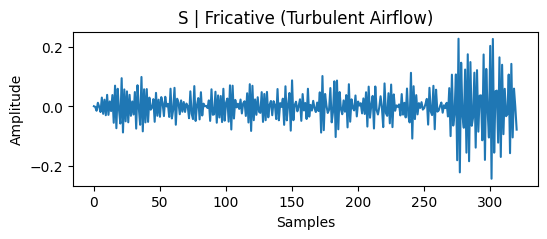

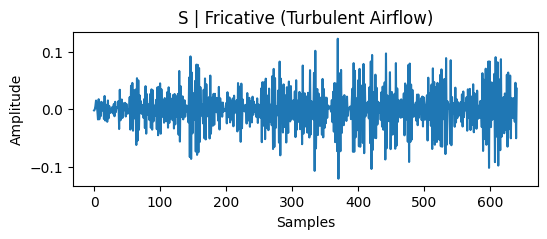

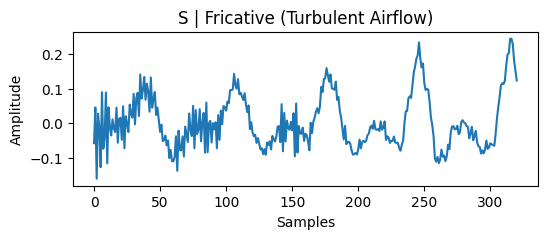

Lab-3 Phoneme Segmentation and Voicing Analysis Completed Successfully


In [3]:
!pip install librosa soundfile transformers torch matplotlib
# ================================
# SPEECH PROCESSING LAB – 3
# Phoneme Segmentation & Voicing Analysis
# ================================

import librosa
import numpy as np
import torch
import matplotlib.pyplot as plt
import soundfile as sf
from transformers import Wav2Vec2Processor, Wav2Vec2ForCTC

# ---------- 1. LOAD & PREPROCESS AUDIO ----------
audio_path = "/content/drive/MyDrive/Speech processing/LJ001-0001.wav"   # replace with your recorded wav file

audio, sr = librosa.load(audio_path, sr=None, mono=True)

target_sr = 16000
if sr != target_sr:
    audio = librosa.resample(audio, orig_sr=sr, target_sr=target_sr)
    sr = target_sr

# ---------- 2. LOAD WAV2VEC2 MODEL ----------
processor = Wav2Vec2Processor.from_pretrained("facebook/wav2vec2-base-960h")
model = Wav2Vec2ForCTC.from_pretrained("facebook/wav2vec2-base-960h")
model.eval()

# ---------- 3. PHONEME RECOGNITION ----------
inputs = processor(audio, sampling_rate=sr, return_tensors="pt", padding=True)

with torch.no_grad():
    logits = model(inputs.input_values).logits

predicted_ids = torch.argmax(logits, dim=-1)
tokens = processor.tokenizer.convert_ids_to_tokens(predicted_ids[0])

# ---------- 4. PHONEME SEGMENTATION ----------
time_per_step = audio.shape[0] / logits.shape[1] / sr

phonemes = []
start = 0
prev = tokens[0]

for i, tok in enumerate(tokens):
    if tok != prev:
        end = i
        if prev != "|":
            phonemes.append((prev, start * time_per_step, end * time_per_step))
        start = i
        prev = tok

if prev != "|":
    phonemes.append((prev, start * time_per_step, len(tokens) * time_per_step))

# ---------- 5. PHONEME CLASSIFICATION ----------
def phoneme_category(ph):
    if ph in ["AA","AE","AH","EH","IH","IY","OW","UH","UW"]:
        return "Vowel (Voiced)"
    elif ph in ["P","T","K","F","S","SH","CH"]:
        return "Unvoiced Consonant"
    elif ph in ["B","D","G","Z","V"]:
        return "Voiced Consonant"
    elif ph in ["M","N","NG"]:
        return "Nasal"
    elif ph in ["Y","J","W","R","L"]:
        return "Approximant"
    else:
        return "Other"

voiced_segment = None
unvoiced_segment = None

# ---------- 6. EXTRACT, SAVE & PLOT PHONEMES ----------
for idx, (ph, t1, t2) in enumerate(phonemes):
    s = int(t1 * sr)
    e = int(t2 * sr)
    segment = audio[s:e]

    if len(segment) < 50:
        continue

    label = phoneme_category(ph)

    sf.write(f"phoneme_{idx}_{ph}.wav", segment, sr)

    plt.figure(figsize=(6,2))
    plt.plot(segment)
    plt.title(f"Phoneme: {ph} | {label}")
    plt.xlabel("Samples")
    plt.ylabel("Amplitude")
    plt.show()

    if "Voiced" in label and voiced_segment is None:
        voiced_segment = segment
    if "Unvoiced" in label and unvoiced_segment is None:
        unvoiced_segment = segment

# ---------- 7. VOICED vs UNVOICED COMPARISON ----------
plt.figure(figsize=(10,3))

plt.subplot(1,2,1)
plt.plot(voiced_segment)
plt.title("Voiced Segment – Periodic Structure")
plt.xlabel("Samples")

plt.subplot(1,2,2)
plt.plot(unvoiced_segment)
plt.title("Unvoiced Segment – Noise-like Structure")
plt.xlabel("Samples")

plt.tight_layout()
plt.show()

# ---------- 8. FRICATIVE vs APPROXIMANT ANALYSIS ----------
fricatives = ["S", "SH", "Z"]
approximants = ["Y", "J"]

for ph, t1, t2 in phonemes:
    if ph in fricatives or ph in approximants:
        s = int(t1 * sr)
        e = int(t2 * sr)
        segment = audio[s:e]

        if len(segment) < 50:
            continue

        plt.figure(figsize=(6,2))
        plt.plot(segment)
        plt.title(
            f"{ph} | {'Fricative (Turbulent Airflow)' if ph in fricatives else 'Approximant (Laminar Airflow)'}"
        )
        plt.xlabel("Samples")
        plt.ylabel("Amplitude")
        plt.show()

print("Lab-3 Phoneme Segmentation and Voicing Analysis Completed Successfully")
